# Prelim

In [ ]:
library(dplyr)
library(ggplot2)
library(bedtoolsr)
library(data.table)
library(easylift)
library(patchwork)
library(ggridges)
library(tidyverse)
library(easylift)
library(ggsignif)

fig_size <- function(width, heigth){
 options(repr.plot.width = width, repr.plot.height = heigth)
}

color_key = list(
    'human gwas' = 'lightpink1',
    'human eqtls' = 'firebrick1',
    'human coloc' = 'firebrick4',
    'pig gwas' = 'lightskyblue1',
    'pig eqtls' = 'royalblue1',
    'pig coloc' = 'navyblue',
    'cattle gwas' = 'mediumpurple1',
    'cattle eqtls' = 'purple',
    'cattle coloc' = 'purple4',
    'human sc-eqtls' = 'orange',
    'human caqtls' = 'gold2'
)

categories_factor = factor(c('human gwas', 'human eqtls', 'human coloc', 'cattle gwas', 'cattle eqtls', 'cattle coloc', 'pig gwas', 'pig eqtls', 'pig coloc', 'human sc-eqtls', 'human caqtls'))

# General functions

In [55]:
lift_hg19_to_hg38 = function(df) {
    if (!('chr' %in% names(df))) stop('df must have a column named chr')
    if (!('start' %in% names(df) && 'end' %in% names(df)) && 'pos' %in% names(df)) {
        df$start = df$end = as.numeric(df$pos)
    } else if (!('start' %in% names(df) && 'end' %in% names(df)) && 'bp' %in% names(df)) {
        df$start = df$end = as.numeric(df$bp)
    } else if (!('start' %in% names(df) && 'end' %in% names(df))) {
        stop('df must have columns named start and end or pos or bp')
    }

    # If chr is not a string or does not start with 'chr', add 'chr' to the beginning
    if (class(df$chr) != 'character' || !all(grepl('^chr', df$chr))) df$chr = paste0('chr', df$chr)

    hg19 = GenomicRanges::makeGRangesFromDataFrame(df, keep.extra.columns=T, ignore.strand=T)
    genome(hg19) = 'hg19'

    chain = '/Users/noah/data/liftover/hg19ToHg38.over.chain' # Note that this cannot be gzipped
    hg38 = easylift::easylift(hg19, to='hg38', chain)

    out = data.frame(hg38)
    if ('pos' %in% names(out)) out$pos = out$end
    if ('bp' %in% names(out)) out$bp = out$end
    out = out %>% dplyr::rename(chr=seqnames) %>% dplyr::select(-width, -strand) #dplyr::select(-start, -end, -strand, -width)
    return(out)
}

lift_hg38_to_hg19 = function(df) {
    if (!('chr' %in% names(df))) stop('df must have a column named chr')
    if (!('start' %in% names(df) && 'end' %in% names(df)) && 'pos' %in% names(df)) {
        df$start = df$end = as.numeric(df$pos)
    } else if (!('start' %in% names(df) && 'end' %in% names(df)) && 'bp' %in% names(df)) {
        df$start = df$end = as.numeric(df$bp)
    } else if (!('start' %in% names(df) && 'end' %in% names(df))) {
        stop('df must have columns named start and end or pos or bp')
    }

    # If chr is not a string or does not start with 'chr', add 'chr' to the beginning
    if (class(df$chr) != 'character' || !all(grepl('^chr', df$chr))) df$chr = paste0('chr', df$chr)

    hg38 = GenomicRanges::makeGRangesFromDataFrame(df, keep.extra.columns=T, ignore.strand=T)
    genome(hg38) = 'hg38'

    chain = '/Users/noah/data/liftover/hg38ToHg19.over.chain' # Note that this cannot be gzipped
    hg19 = easylift::easylift(hg38, to='hg19', chain)

    out = data.frame(hg19)
    if ('pos' %in% names(out)) out$pos = out$end
    if ('bp' %in% names(out)) out$bp = out$end
    out = out %>% dplyr::rename(chr=seqnames) %>% dplyr::select(-width, -strand) #dplyr::select(-start, -end, -strand, -width)
    return(out)
}

add_distance_cmd = function(bed1, bed2, dist_name='dist') {
    write.table(bed1, '~/tmp/bedtools/tmp_bed1.bed', row.names = F, col.names = F, sep = '\t', quote=F)
    write.table(bed2, '~/tmp/bedtools/tmp_bed2.bed', row.names = F, col.names = F, sep = '\t', quote=F)
    system('~/anaconda3/envs/stdpopsim/bin/bedtools sort -i ~/tmp/bedtools/tmp_bed1.bed > ~/tmp/bedtools/tmp_sorted_bed1.bed')
    system('~/anaconda3/envs/stdpopsim/bin/bedtools sort -i ~/tmp/bedtools/tmp_bed2.bed > ~/tmp/bedtools/tmp_sorted_bed2.bed')
    system('~/anaconda3/envs/stdpopsim/bin/bedtools closest -a ~/tmp/bedtools/tmp_sorted_bed1.bed -b ~/tmp/bedtools/tmp_sorted_bed2.bed -D ref -t first > ~/tmp/bedtools/tmp_dists.bed')
    dists = read.table('~/tmp/bedtools/tmp_dists.bed', header = F, stringsAsFactors = F) %>% distinct()
    names(dists) = c('chr', 'start', 'end', 'na1', 'na2', 'na3', dist_name)
    out = left_join(bed1, dists[, c('chr', 'start', 'end', dist_name)], by = join_by('chr', 'start', 'end'))
    system('rm ~/tmp/bedtools/tmp_*.bed')

    return(out)
}

# Read in data

**This section can only be run after you have formatted and saved the data** using the sections "Data acquisition and formatting" and "Running and storing." After those have been run, you can run this section in order to skip those. Make sure `saved_ddir` matches in this section and in "Running and storing." After running you can skip directly to "Organizing data."

In [71]:
saved_ddir = '~/comparative_colocalization/data/intermediate_data/snps_elements_enrichments/'

hgwas = read.table(paste0(saved_ddir, 'hgwas.tsv'), header=T, as.is=T, sep='\t')
cgwas = read.table(paste0(saved_ddir, 'cgwas.tsv'), header=T, as.is=T, sep='\t')
pgwas = read.table(paste0(saved_ddir, 'pgwas.tsv'), header=T, as.is=T, sep='\t')

heqtls = read.table(paste0(saved_ddir, 'heqtls.tsv'), header=T, as.is=T, sep='\t')
ceqtls = read.table(paste0(saved_ddir, 'ceqtls.tsv'), header=T, as.is=T, sep='\t')
peqtls = read.table(paste0(saved_ddir, 'peqtls.tsv'), header=T, as.is=T, sep='\t')

henloc = read.table(paste0(saved_ddir, 'henloc.tsv'), header=T, as.is=T, sep='\t')
cenloc = read.table(paste0(saved_ddir, 'cenloc.tsv'), header=T, as.is=T, sep='\t')
penloc = read.table(paste0(saved_ddir, 'penloc.tsv'), header=T, as.is=T, sep='\t')

htss = read.table(paste0(saved_ddir, 'htss.tsv'), header=T, as.is=T, sep='\t')
ctss = read.table(paste0(saved_ddir, 'ctss.tsv'), header=T, as.is=T, sep='\t')
ptss = read.table(paste0(saved_ddir, 'ptss.tsv'), header=T, as.is=T, sep='\t')

henh = read.table(paste0(saved_ddir, 'henh.tsv'), header=T, as.is=T, sep='\t')
cenh = read.table(paste0(saved_ddir, 'cenh.tsv'), header=T, as.is=T, sep='\t')
penh = read.table(paste0(saved_ddir, 'penh.tsv'), header=T, as.is=T, sep='\t')

hpro = read.table(paste0(saved_ddir, 'hpro.tsv'), header=T, as.is=T, sep='\t')
cpro = read.table(paste0(saved_ddir, 'cpro.tsv'), header=T, as.is=T, sep='\t')
ppro = read.table(paste0(saved_ddir, 'ppro.tsv'), header=T, as.is=T, sep='\t')

null_hpro = sum(hpro$end - hpro$start)/3e9
null_henh = sum(henh$end - henh$start)/3e9
null_ppro = sum(ppro$end - ppro$start)/2.7e9
null_penh = sum(penh$end - penh$start)/2.7e9
null_cpro = sum(cpro$end - cpro$start)/2.7e9
null_cenh = sum(cenh$end - cenh$start)/2.7e9

# These are the single-cell eQTLs
jax = read.table(paste0(saved_ddir, 'hsceqtl.tsv'), header=T, as.is=T, sep='\t')
# hsceqtls = jax # I'm combining code from multiple scripts and this is just easier. Sorry.
ca = read.table(paste0(saved_ddir, 'hcaqtl.tsv'), header=T, as.is=T, sep='\t')
pig_vars_hg38 = read.table('~/tmp/pig_variants_hg38.bed', col.names=c('chr', 'start', 'end'))


# Data acquisition and formatting

## TSS

Transcription start sites were downloaded from UCSC Table Browser with the following data

Human
- Assembly: `GRCh38/hg38`
- Group: `Genes and Gene Predictions`
- Track: `GENCODE V49`
- Table `knownGene`
    - Fields: `name`, `chrom`, `strand`, `txStart`, `txEnd`, `alignID`
- Table `kgXref` (included by using the output format "Selected fields from primary and related tables")
    - Fields: `geneSymbol`

Cattle
- Assembly: `Dec. 2013 (ARS-UCD1.2/bosTau9)`
- Group: `Genes and Gene Predictions`
- Track: `NCBI RefSeq`
- Table: `RefSeq All (ncbiRefSeq)`
    - Fields: `name`, `chrom`, `strand`, `txStart`, `txEnd`, `name2`

Pig
- Assembly: `Feb 2017 (Sscrofa11.1/susScr11)`
- Group: `Genes and Gene Predictions`
- Track: `NCBI RefSeq`
- Table: `RefSeq All (ncbiRefSeq)`
    - Fields: `name`, `chrom`, `strand`, `txStart`, `txEnd`, `name2`

In [4]:
tss_ddir = '~/data/tss_ucsc/'
# Also need to create an empty directory for bedtools to temporarily store files in
# Here that's ~/tmp/bedtools/

extend_bed = function(bed, extension=0) {
    if (extension == 0) {
        return(bed)
    }

    bed = bed %>% dplyr::mutate(start = start - extension, end = end + extension) %>%
        dplyr::mutate(start = ifelse(start < 0, 0, start))
    return(bed)
}

add_tss_distance_cmd = function(snps, tss) {
    # remove_cols = T
    if ('start' %in% names(snps) && 'end' %in% names(snps)) {
        # We don't actually do anything here, it's just a more readable set of else ifs
        # remove_cols = F
        x = 1
    } else if ('pos' %in% names(snps)) {
        snps$end = as.numeric(snps$pos)
        snps$start = snps$end - 1
    } else if ('bp' %in% names(snps)) {
        snps$end = as.numeric(snps$bp)
        snps$start = snps$end - 1
    } else {
        print(names(snps))
        stop('snps must have start and end columns, or pos, or bp')
    }
    if (identical(names(tss), c('V1', 'V2', 'V3'))) {
        names(tss) = c('chr', 'start', 'end')
    }
    bed = snps[,c('chr', 'start', 'end')]
    write.table(bed, '~/tmp/bedtools/tmp_snps.bed', row.names = F, col.names = F, sep = '\t', quote=F)
    write.table(tss, '~/tmp/bedtools/tmp_tss.bed', row.names = F, col.names = F, sep = '\t', quote=F)
    system('~/anaconda3/envs/stdpopsim/bin/bedtools sort -i ~/tmp/bedtools/tmp_snps.bed > ~/tmp/bedtools/tmp_sorted_snps.bed')
    system('~/anaconda3/envs/stdpopsim/bin/bedtools sort -i ~/tmp/bedtools/tmp_tss.bed > ~/tmp/bedtools/tmp_sorted_tss.bed')
    system('~/anaconda3/envs/stdpopsim/bin/bedtools closest -a ~/tmp/bedtools/tmp_sorted_snps.bed -b ~/tmp/bedtools/tmp_sorted_tss.bed -D ref -t first > ~/tmp/bedtools/tmp_dists.bed')
    dists = read.table('~/tmp/bedtools/tmp_dists.bed', header = F, stringsAsFactors = F) %>% distinct()
    names(dists) = c('chr', 'start', 'end', 'na1', 'na2', 'na3', 'tss_dist')
    snps = left_join(snps, dists[, c('chr', 'start', 'end', 'tss_dist')], by = join_by('chr', 'start', 'end'))
    
    return(snps)
}

# read_pig_tss = function() {
#     tss = read.table(paste0('~/data/tss_ucsc/', 'pig_encode_genes.txt'), header=T, as.is=T, na.strings=c('NA', ''), comment.char='', sep='\t') %>%
#         mutate(chr = chrom, start = txStart - 1, end = txStart) %>%
#         mutate(gene = gsub('\\..*', '', name)) %>%
#         select(chr, start, end, gene, strand) %>% 
#         mutate(start = ifelse(start < 0, 0, start), end = ifelse(end < 1, 1, end)) %>%
#         filter(chr %in% paste0('chr', 1:18))
#     tss_sorted = bedtoolsr::bt.sort(tss %>% select(chr, start, end) %>% distinct())
#     names(tss_sorted) = c('chr', 'start', 'end')
#     tss = left_join(tss_sorted, tss, by=c('chr', 'start', 'end'), multiple='all')
#     return(tss)
# }

read_pig_tss_bed = function() {
    tss = read.table(paste0(tss_ddir, 'pig_encode_genes.txt'), header=T, as.is=T, na.strings=c('NA', ''), comment.char='', sep='\t') %>%
        mutate(chr = chrom, start = txStart - 1, end = txStart) %>%
        mutate(gene = gsub('\\..*', '', name)) %>%
        select(chr, start, end, gene, strand) %>% 
        mutate(start = ifelse(start < 0, 0, start), end = ifelse(end < 1, 1, end)) %>%
        filter(chr %in% paste0('chr', 1:18))
    tss = bedtoolsr::bt.sort(tss %>% select(chr, start, end))
    names(tss) = c('chr', 'start', 'end')
    # tss = left_join(tss_sorted, tss, by=c('chr', 'start', 'end'))
    return(tss)
}

read_human_tss_bed = function() {
    tss = read.table(paste0(tss_ddir, 'unique_genes_tss_hgTables_gencode.txt'), header=T, as.is=T, na.strings=c('NA', ''), comment.char='', sep='\t') %>%
        dplyr::mutate(chr = hg38.knownGene.chrom, start = hg38.knownGene.txStart - 1, end = hg38.knownGene.txStart) %>%
        dplyr::select(chr, start, end) %>%
        dplyr::mutate(start = ifelse(start < 0, 0, start), end = ifelse(end < 1, 1, end)) %>%
        dplyr::filter(chr %in% paste0('chr', 1:22))
    tss = bedtoolsr::bt.sort(tss)
    names(tss) = c('chr', 'start', 'end')
    return(tss)
}

read_cattle_tss_bed = function() {
    tss = read.table(paste0(tss_ddir, 'cow_tss_hgTables.txt'), header=T, as.is=T, na.strings=c('NA', ''), comment.char='', sep='\t')
    names(tss) = c('gene', 'chr', 'stand', 'txStart', 'txEnd', 'name2')
    tss = tss %>% dplyr::mutate(start = txStart - 1, end = txStart) %>%
        dplyr::select(chr, start, end) %>%
        dplyr::mutate(start = ifelse(start < 0, 0, start), end = ifelse(end < 1, 1, end)) %>%
        dplyr::filter(chr %in% paste0('chr', 1:22))
    tss = bedtoolsr::bt.sort(tss)
    names(tss) = c('chr', 'start', 'end')
    return(tss)
}


## Promoters and enhancers

Data for promters and enhancers were downloaded from

Humans: https://egg2.wustl.edu/roadmap/web_portal/chr_state_learning.html#exp_18state

Cattle: http://farm.cse.ucdavis.edu/~ckern/Nature_Communications_2020/Chromatin_State_Predictions/

Pigs: http://farm.cse.ucdavis.edu/zhypan/Nature_Communications_2021 (can also be found at https://doi.org/10.6084/m9.figshare.13480425)

I used awk to pull out the relevant annotations and combine tissues into one file. This could also easily be accomplished in R.

Commands for pigs were:

`awk '$4 == "e6"' _15_segments.bed > pig_e6_enhancers.bed`

`awk '$4 == "e1"' _15_segments.bed > pig_e1_promoters.bed`

Commands for cattle were:

`awk '$4 == "E4"' Cattle_*_segmentsbed > njc_cattle_combined_tissues_e4_active_promoters.bed`

`awk '$4 == "E7"' *bed > njc_cattle_combined_tissues_e7_active_enhancers.bed`


In [5]:
human_annot_dir = '~/eqtl_selection/data/chromhmm/hchromhmm/18_state_model/hg38/'
pig_annot_dir = '~/eqtl_selection/data/chromhmm/pchromhmm/pan_2021/'
cattle_annot_dir = '~/eqtl_selection/data/chromhmm/cchromhmm/'

sort_bed_cmd = function(bed) {
    write.table(bed, '~/tmp/bedtools/tmp_bed.bed', row.names=F, col.names=F, quote=F, sep='\t')
    system('~/anaconda3/envs/stdpopsim/bin/bedtools sort -i ~/tmp/bedtools/tmp_bed.bed > ~/tmp/bedtools/tmp_sorted_bed.bed')
    return(read.table('~/tmp/bedtools/tmp_sorted_bed.bed', header=F, as.is=T, sep='\t', col.names=c('chr', 'start', 'end')))
}

sort_merge_bed_cmd = function(bed) {
    bed$start = as.integer(bed$start)
    bed$end = as.integer(bed$end)
    write.table(bed, '~/tmp/bedtools/tmp_bed.bed', row.names=F, col.names=F, quote=F, sep='\t')
    system('~/anaconda3/envs/stdpopsim/bin/bedtools sort -i ~/tmp/bedtools/tmp_bed.bed > ~/tmp/bedtools/tmp_sorted_bed.bed')
    system('~/anaconda3/envs/stdpopsim/bin/bedtools merge -i ~/tmp/bedtools/tmp_sorted_bed.bed > ~/tmp/bedtools/tmp_merged_bed.bed')
    out = read.table('~/tmp/bedtools/tmp_merged_bed.bed', header=F, as.is=T, sep='\t', col.names=c('chr', 'start', 'end'))
    system('rm ~/tmp/bedtools/tmp_bed.bed ~/tmp/bedtools/tmp_sorted_bed.bed ~/tmp/bedtools/tmp_merged_bed.bed')
    return(out)
}

read_human_enh = function(min=41) {
    out = read.table(paste0(human_annot_dir, 'genomecov_bg_all_18_state_enh.bed.gz'),
        col.names=c('chr', 'start', 'end', 'gen_count'), header=F, as.is=T, sep='\t',
        colClasses=c('character', 'integer', 'integer', 'integer')) %>% 
        dplyr::filter(gen_count >= min) %>% select(chr, start, end)
    
    return(sort_merge_bed_cmd(out))
}

read_human_pro = function(min=41) {
    out = read.table(paste0(human_annot_dir, 'genomecov_bg_all_18_state_pro.bed.gz'),
        col.names=c('chr', 'start', 'end', 'gen_count'), header=F, as.is=T, sep='\t',
        colClasses=c('character', 'integer', 'integer', 'integer')) %>% 
        dplyr::filter(gen_count >= min) %>% select(chr, start, end)
    
    return(sort_merge_bed_cmd(out))
}

read_pig_enh = function(enh_rank=1) {
    ranks = c('E6', 'E7', 'E8', 'E9')[1:enh_rank]
    out = read.table(paste0(pig_annot_dir, 'pig_e6_enhancers.bed'))
    names(out) = c('chr', 'start', 'end')
    out$start = as.numeric(out$start)
    out$end = as.numeric(out$end)

    return(sort_merge_bed_cmd(out))
}

read_pig_pro = function() {
    out = read.table(paste0(pig_annot_dir, 'pig_e1_promoters.bed'))
    names(out) = c('chr', 'start', 'end')
    out$start = as.numeric(out$start)
    out$end = as.numeric(out$end)
    
    return(sort_merge_bed_cmd(out))
}

read_cattle_enh = function(tissues=c()) {
    if (length(tissues) == 0) {
        out = read.table(paste0(cattle_annot_dir, 'njc_cattle_combined_tissues_e7_active_enhancers.bed'),
                header=F, as.is=T, sep='\t', col.names=c('chr', 'start', 'end', 'state')) %>% dplyr::select(-state)
    }
    out$start = as.numeric(out$start)
    out$end = as.numeric(out$end)
    
    return(sort_merge_bed_cmd(out))
}

read_cattle_pro = function(tissues=c()) {
    if (length(tissues) == 0) {
        out = read.table(paste0(cattle_annot_dir, 'njc_cattle_combined_tissues_e4_active_promoters.bed'),
                header=F, as.is=T, sep='\t', col.names=c('chr', 'start', 'end', 'state')) %>% dplyr::select(-state)
    }
    out$start = as.numeric(out$start)
    out$end = as.numeric(out$end)
    
    return(sort_merge_bed_cmd(out))
}

## Fine-mapped GWAS

Human data were downloaded from [CausalDB](http://www.mulinlab.org/causaldb) ([specific data here](https://my.microsoftpersonalcontent.com/personal/f7bb08e3479fe7ea/_layouts/15/download.aspx?UniqueId=479fe7ea-08e3-20bb-80f7-c51200000000&Translate=false&tempauth=v1e.eyJzaXRlaWQiOiI1ZjhmMjRhNC1hZTEzLTQ4NWEtOWIxZS0zZjRiNWM0ODE4YzIiLCJhdWQiOiIwMDAwMDAwMy0wMDAwLTBmZjEtY2UwMC0wMDAwMDAwMDAwMDAvbXkubWljcm9zb2Z0cGVyc29uYWxjb250ZW50LmNvbUA5MTg4MDQwZC02YzY3LTRjNWItYjExMi0zNmEzMDRiNjZkYWQiLCJleHAiOiIxNzYyODEwNzEwIn0.06YbmoRpXtaJDMnGr8tt6eyXghwFBjBK9ceSDaTBaogmnHOxYHBfD1c3MAW_lEoA4JEejx1TSJDgrzvAsxjjJrQsEx6cp_8NcCO-WfQSUL1kq2BNp8YgvSH2Cp1ZhABtNqF-QAjgSIBjrNvl62g-RYBHZgqcd9rP1GqbTsGVYdaaS5hIl-8f0KrHZtnbuwwOgZN6wa_zOp8FqAluss_pKiNtTm6thLDPyPlimSW2VPjoV0irKwdT69NtNcGucqZxF1quzXUgyiIJK5ppyapShrYaROzNu7oReNtbROPC4pXg3gbvnZ5EJ2u8OXgJNGpqYPfo1xcmbLSE_HTRMOPOkIlJ8r67Vb6Va49g1iFCKRAwGycRgs0M9-GkYFpi9NV9Gl8Yq82Pd_WVC1K1f4_TdP4uSwFUsXbw6Akqdr0FF-oQ6nFTBBAD0MiaLLTs3u0s2Y1Q87SycrVYZQHv8PiXb5374kUxWtUQk6bZq8SnkMfGBCoylFKfh25lykjIsqocJXh-4BZiNUGJXM0z75gU1g.hbJh6LiDX7XoR78z8a9PbfV_zlSa-2c_4Sqd_fetHuc&ApiVersion=2.0))

Then filtered with

'mkdir subsetting'

`awk '$20 > 0.5' credible_set.txt > subsetting/credible_set_polyfun_susie_gt_50percent.txt`

Cattle data were downloaded from [Jiang *et al.* 2019](https://www.nature.com/articles/s42003-019-0454-y) ([specific file here](https://static-content.springer.com/esm/art%3A10.1038%2Fs42003-019-0454-y/MediaObjects/42003_2019_454_MOESM4_ESM.xlsx))
- Renamed `42003_2019_454_MOESM4_ESM.xlsx` to `jiang_2019.xlsx`

Pig data were extracted from the fastEnloc data (see that section)

In [ ]:
human_fm_ddir = '~/data/finemapping/causalDB/v2.1/subsetting/'
cattle_fm_ddir = '~/comparative_colocalization/data/gwas/cattle_gwas/fine-mapping/'
pig_enloc_ddir = '~/eqtl_selection/data/enloc/penloc/Muscle'

read_human_fm_gwas = function(traits=c(), pip=0, tss=NULL, pro=NULL, enh=NULL) {
    print('This is hg19 but has been lifted to hg38')
    if (length(traits) == 0) {
        # fm = read.table(paste0(human_fm_ddir, 'credible_set_polyfun_susie_gt_50percent.txt'), header=T, as.is=T, sep='\t') %>% 
        fm = read.table(paste0(human_fm_ddir, 'credible_set_polyfun_susie_gt_50percent.txt'), header=T, as.is=T, sep='\t') %>% 
            dplyr::filter(polyfun_susie > 0.5) %>%
            dplyr::group_by(meta_id, block_id) %>% 
            dplyr::arrange(desc(susie)) %>% # Changed from polyfun_susie
            dplyr::filter(susie >= pip) %>% 
            dplyr::slice(1) %>%
            dplyr::ungroup() %>% 
            dplyr::mutate(bp = as.numeric(bp))
    } else {
        fm = read.table(paste0(human_fm_ddir, 'credible_set.txt'), header=T, as.is=T, sep='\t') %>% 
            dplyr::filter(polyfun_susie > 0.5) %>%
            dplyr::filter(meta_id %in% traits) %>%
            dplyr::group_by(meta_id, block_id) %>% 
            dplyr::arrange(desc(susie)) %>% # Changed from polyfun_susie
            dplyr::slice(1) %>%
            dplyr::ungroup() %>% 
            dplyr::mutate(bp = as.numeric(bp))
    }
    fm = lift_hg19_to_hg38(fm)
    
    fm = fm %>% 
        dplyr::rename(pos=bp, a1=nea, a2=ea, trait=meta_id) %>% 
        mutate(start = pos-1, end=pos, pip=susie, variant=paste(chr, pos, a1, a2, sep=':')) %>% 
        select(trait, chr, start, end, variant, rsid, a1, a2, maf, beta, se, p, pip)
    
    if (!is.null(tss)) {
        snps = fm %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, tss, 'tss_dist')
        fm = fm %>% left_join(snps, by=c('chr', 'start', 'end'))
    }
    if (!is.null(pro)) {
        snps = fm %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, pro, 'pro_dist')
        fm = fm %>% left_join(snps, by=c('chr', 'start', 'end'))
    }
    if (!is.null(enh)) {
        snps = fm %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, enh, 'enh_dist')
        fm = fm %>% left_join(snps, by=c('chr', 'start', 'end'))
    }

    return(fm)
}

read_pig_fm_gwas = function(files=c(), pip=0, tss=NULL, pro=NULL, enh=NULL) {
    fm = NULL
    files = list.files(pig_enloc_ddir, pattern='\\.enloc\\.snp\\.out', full.names=T)
    
    for (file in files) {
        tr = gsub('.*/', '', gsub('\\.enloc\\.snp\\.out', '', file))
        tmp = read.table(file, header=T, as.is=T) %>% # fm = readr::read_table(file, col_names=T) %>% # Had to remove sep='\t' because files are weird
            dplyr::filter(PIP_gwas_marginal >= pip) %>%
            tidyr::separate_wider_delim(Signal, delim='(@)', names=c('region', 'na1')) %>% 
            dplyr::select(-na1) %>%
            dplyr::group_by(region) %>%
            dplyr::arrange(desc(PIP_gwas_marginal)) %>%
            dplyr::slice(1) %>%
            dplyr::ungroup() %>%
            tidyr::separate_wider_delim(SNP, delim='_', names=c('chr', 'bp', 'a1', 'a2'), cols_remove=F) %>%
            dplyr::mutate(bp = as.numeric(bp)) %>% 
            dplyr::mutate(chr = paste0('chr', chr), bp = as.numeric(bp), trait=tr) %>% 
            tidyr::separate_wider_delim(trait, delim='.', names=c('tissue', 'trait'))

        fm = rbind(fm, tmp)
    }
    
    fm = fm %>% 
        dplyr::rename(pip = PIP_gwas_marginal) %>% 
        mutate(start=bp-1, end=bp, variant = paste(chr, bp, a1, a2, sep=':')) %>%
        select(trait, chr, start, end, variant, a1, a2, pip)
    
    if (!is.null(tss)) {
        snps = fm %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, tss, 'tss_dist')
        fm = fm %>% left_join(snps, by=c('chr', 'start', 'end'))
    }
    if (!is.null(pro)) {
        snps = fm %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, pro, 'pro_dist')
        fm = fm %>% left_join(snps, by=c('chr', 'start', 'end'))
    }
    if (!is.null(enh)) {
        snps = fm %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, enh, 'enh_dist')
        fm = fm %>% left_join(snps, by=c('chr', 'start', 'end'))
    }

    return(fm)
}

read_cattle_fm_gwas = function(pip=0, tss=NULL, pro=NULL, enh=NULL) {
    fm = readxl::read_excel(paste0(cattle_fm_ddir, 'jiang_2019.xlsx'), sheet='S13') %>%
        separate_rows(Traits, PPC, Pval, sep='\\|') %>% 
        filter(PPC >= pip) %>%
        separate_wider_delim(Variant, delim=':', names=c('chr', 'bp'), cols_remove=F) %>%
        mutate(chr = paste0('chr', chr), start=as.numeric(bp)-1, end=as.numeric(bp), variant=paste(Variant, Ref, Alt, sep=':')) %>% 
        dplyr::rename(pip = PPC, a1=Ref, a2=Alt, maf=MAF, p=Pval, trait=Traits) %>%
        select(trait, chr, start, end, variant, a1, a2, pip)

    if (!is.null(tss)) {
        snps = fm %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, tss, 'tss_dist')
        fm = fm %>% left_join(snps, by=c('chr', 'start', 'end'))
    }
    if (!is.null(pro)) {
        snps = fm %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, pro, 'pro_dist')
        fm = fm %>% left_join(snps, by=c('chr', 'start', 'end'))
    }
    if (!is.null(enh)) {
        snps = fm %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, enh, 'enh_dist')
        fm = fm %>% left_join(snps, by=c('chr', 'start', 'end'))
    }

    return(fm)
}

## eQTLs

Human fine-mapped eQTLs were downloaded from [GTEx](https://storage.googleapis.com/adult-gtex/bulk-qtl/v8/fine-mapping-cis-eqtl/GTEx_v8_finemapping_DAPG.tar)

Then processed with

`for fl in $(ls *signif*); do tis=$(echo $fl | sed -E 's/.v8.*//g'); echo $tis; awk -v TIS=$tis 'FNR > 1 {print TIS"\t"$1"\t"$2"\t"$3}' <(gzcat $fl) >> all_eqtl_tss_dist.tsv; done`

`awk 'NR == FNR {variants[$1":"$2":"$5]=1; next} NR != FNR && $1":"$3":"$2 in variants {print $0}' <(gzcat ~/eqtl_selection/data/gtex/hgtex/finemapped/GTEx_v8_finemapping_DAPG/GTEx_v8_finemapping_DAPG.txt.gz) all_eqtl_tss_dist.tsv | gzip > finemapped_eqtl_tss_dist.tsv.gz`

---------------------

Pig fine-mapped eQTLs were downloaded from the Pig GTEx Project
- Go to site https://piggtex.farmgtex.org/, then the Downloads tab, then select `PigGTEx_v0.finemapped_eQTL.tar.gz`

---------------------

Cattle fine-mapped eQTLs were downloaded from [Figshare](https://figshare.com/articles/dataset/cis-eQTLs_for_24_tissues/22262575?file=39570028)

`head -n 1 Adipose.finemap.eQTL.txt > cattle_eqtls.all.txt`
`for file in $(ls *.finemap.eQTL.txt); do`
`   tis_name = $(echo $file | sed 's/.finemap.eQTL.txt//g')`
`   awk -v tis=$tis_name '{print $0"\t"tis} $file >> cattle_eqtls.all.txt`
`done`

In [7]:
human_eqtl_ddir = '~/eqtl_selection/data/gtex/hgtex/finemapped/GTEx_v8_finemapping_DAPG/'
pig_eqtl_ddir = '~/eqtl_selection/data/gtex/pgtex/eqtls_susie/PigGTEx_v0.finemapped_eQTL/'
cattle_eqtl_ddir = '~/comparative_colocalization/data/gtex/cgtex/cGTEx/finemapping/fine_map_eQTL/'

read_human_fm_eqtls = function(tissues=c(), pip=0, cs_pip=0, pro=NULL, enh=NULL, tss=NULL) {
    print('Remember, you have to line up the cluster PIPs with pigs at some point. Using the susie default of 90%.')
    all = (length(tissues) == 0)
    # print(all)

    eqtls = read.table(paste0(human_eqtl_ddir, 'GTEx_v8_finemapping_DAPG.txt.gz'),
            header=T, as.is=T, sep='\t')
    # Key was created with script above
    tss_dist_key = read.table(paste0(human_eqtl_ddir, 'finemapped_eqtl_tss_dist.tsv.gz'), col.names=c('tissue_id', 'variant_id', 'gene_id', 'tss_dist'))
    eqtls = left_join(eqtls, tss_dist_key, by=c('tissue_id', 'variant_id', 'gene_id'))

    eqtls = eqtls %>% 
        dplyr::mutate(variant_pip = as.numeric(variant_pip)) %>%
        dplyr::filter(cluster_pip >= cs_pip) %>% 
        dplyr::filter(variant_pip >= pip) %>%
        dplyr::filter(all | tissue_id %in% tissues) %>%
        dplyr::group_by(tissue_id, gene_id, cluster_id) %>%
        dplyr::arrange(desc(variant_pip)) %>%
        dplyr::slice(1) %>%
        dplyr::ungroup() %>%
        tidyr::separate_wider_delim(variant_id, delim='_', names=c('chr', 'pos', 'a1', 'a2', 'build'), cols_remove=F) %>% 
        dplyr::mutate(pos = as.numeric(pos))
    
    eqtls = eqtls %>% 
        dplyr::rename(tissue=tissue_id, pip=variant_pip) %>% 
            mutate(variant=paste(chr, pos, a1, a2, sep=':'),
                gene=gsub('\\..*', '', gene_id),
                start=pos-1, end=pos) %>% 
            select(tissue, gene, chr, start, end, a1, a2, variant, cluster_pip, pip, tss_dist)

    if (!is.null(pro)) {
        snps = eqtls %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, pro, 'pro_dist')
        eqtls = eqtls %>% left_join(snps, by=c('chr', 'start', 'end'))
    }
    if (!is.null(enh)) {
        snps = eqtls %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, enh, 'enh_dist')
        eqtls = eqtls %>% left_join(snps, by=c('chr', 'start', 'end'))
    }
    if (!is.null(tss)) {
        snps = eqtls %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, tss, dist_name='nearest_tss_dist')
        eqtls = eqtls %>% left_join(snps, by=c('chr', 'start', 'end'))
    }

    return(eqtls)
}

read_pig_fm_eqtls = function(tissue=c(), pip=0, pro=NULL, enh=NULL, tss=NULL) {
    print('Remember, you have to line up the cluster PIPs with humans at some point. Susie-inf default is 90% for a credible set')
    
    eqtls = read.table(paste0(pig_eqtl_ddir, 'pgtex.susieinf.all_tis_cs1.txt'), header=T, as.is=T, sep='\t')
    tss_dist_key = read.table('~/eqtl_selection/data/gtex/pgtex/eqtls/pig_eqtl_tss_dist.tsv.gz',
        header=F, as.is=T, col.names=c('tissue', 'gene_id', 'variant_id', 'tss_dist'))
    eqtls = left_join(eqtls, tss_dist_key, by=c('tissue', 'gene_id', 'variant_id'))
    
    eqtls = eqtls %>% dplyr::filter(prob >= pip) %>% 
        dplyr::group_by(tissue, gene_id) %>%
        dplyr::filter(prob == max(prob)) %>%
        dplyr::ungroup() %>%
        tidyr::separate_wider_delim(variant_id, delim='_', names=c('chr', 'pos', 'a1', 'a2'), cols_remove=F) %>%
        dplyr::select(tissue, gene_id, chr, pos, a1, a2, zval, prob, tss_dist) %>% 
        dplyr::mutate(chr = paste0('chr', chr), pos = as.numeric(pos))


    eqtls = eqtls %>% dplyr::rename(gene=gene_id, pip=prob) %>%
        mutate(variant=paste(chr, pos, a1, a2, sep=':'), start=pos-1, end=pos) %>%
        select(tissue, gene, chr, start, end, a1, a2, variant, pip, tss_dist)

    # ptss_genes = read_pig_tss() %>% select(-strand)
    # names(ptss_genes) = c('chr', 'tx_start', 'tx_end', 'gene')

    # eqtls = eqtls %>% left_join(ptss_genes, by=c('chr', 'gene'))
    # eqtls = eqtls %>%
    #     mutate(
    #         tss_dist1 = tx_start - end,
    #         tss_dist2 = start - tx_end,
    #         overlap = (start > tx_start & start < tx_end) | (end > tx_start & end < tx_end) | (start < tx_start & end > tx_end)
    #     ) %>%
    #     mutate(tss_dist = ifelse(overlap, 0, ifelse(abs(tss_dist1) < abs(tss_dist2), tss_dist1, tss_dist2))) %>% 
    #     select(-tss_dist1, -tss_dist2, -overlap, -tx_start, -tx_end)

    if (!is.null(pro)) {
        snps = eqtls %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, pro, 'pro_dist')
        eqtls = eqtls %>% left_join(snps, by=c('chr', 'start', 'end'))
    }
    if (!is.null(enh)) {
        snps = eqtls %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, enh, 'enh_dist')
        eqtls = eqtls %>% left_join(snps, by=c('chr', 'start', 'end'))
    }
    if (!is.null(tss)) {
        snps = eqtls %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, tss, dist_name='nearest_tss_dist')
        eqtls = eqtls %>% left_join(snps, by=c('chr', 'start', 'end'))
    }

    return(eqtls)
}

read_cattle_fm_eqtls = function(pip=0.9, pro=NULL, enh=NULL, tss=NULL) {
    if (pip != 0.9) {
        print('Only pip >= 0.9 eQTL fine-mapping data are available for cattle')
        return()
    }
    
    eqtls = read.table(paste0(cattle_eqtl_ddir, 'cattle_eqtls.all.txt'), header=T, as.is=T)
    
    eqtls = eqtls %>% tidyr::separate_wider_delim(snp, '_', names=c('chr', 'end', 'a1', 'a2')) %>% 
        mutate(chr = paste0('chr', chr), start=as.numeric(end)-1, end = as.numeric(end)) %>%
        mutate(variant = paste(chr, end, a1, a2, sep=':')) %>%
        dplyr::rename(beta=slope) %>%
        select(tissue, gene, chr, start, end, a1, a2, variant, beta, maf, tss_dist)

    if (!is.null(pro)) {
        snps = eqtls %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, pro, 'pro_dist')
        eqtls = eqtls %>% left_join(snps, by=c('chr', 'start', 'end'))
    }
    if (!is.null(enh)) {
        snps = eqtls %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, enh, 'enh_dist')
        eqtls = eqtls %>% left_join(snps, by=c('chr', 'start', 'end'))
    }
    if (!is.null(tss)) {
        snps = eqtls %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, tss, dist_name='nearest_tss_dist')
        eqtls = eqtls %>% left_join(snps, by=c('chr', 'start', 'end'))
    }

    return(eqtls)
}

## fastEnloc data

Human data were from Pividori *et al.* 2021 ([downloaded from Zenodo](https://zenodo.org/records/3911190/files/fastenloc-torus-rcp.tsv.gz?download=1))

Pig data were from the Pig GTEx paper (go to [this SciDB site](https://www.scidb.cn/en/detail?dataSetId=8ac8e02486644279bffb634597ae6b47), click "PigGTEx_v0.fastENLOC_results", then "GWAS_and_eQTL")

Human data then need to be collected with awk to combine phenotypes and tissues.

Because we're looking for the lead SNP of each colocalization, we want the files ending in `.enloc.snp.out` which contain the regional colocalization probability (RCP) in addition to the SNP data.

`awk 'BEGIN {OFS="\t"; print "gene\tsnp\teqtl_pip\tgwas_pip\tgwas_pip_w_eqtl_prior\trcp\tfile"} $6 > 0.5 {print $0"\t"FILENAME}' \`

`    */*/*.enloc.snp.out > human_fastenloc_hits_w_filename.tsv`

**Still need to add code that pulled out GTEx data with TSS distances**

FastEnloc files were not published with the Cattle GTEx paper. However, the signficant results can be obtained in a roundabout way.

Download the supplementary colocalization plots for Liu *et al.* 2022 from https://cgtex.roslin.ed.ac.uk/wp-content/plugins/cgtex/static/rawdata/Coloc_Plots.zip

Scrape the names, each of which is a concatenated line from the fastEnloc output.

`wget --no-check-certificate https://cgtex.roslin.ed.ac.uk/wp-content/plugins/cgtex/static/rawdata/Coloc_Plots.zip`

`unzip Coloc_Plots.zip`

`ls *.pdf | sed 's/.plot.pdf//g' | tr '.' '\t' | tr '_' '\t' > njc_cattle_colocalization_list.tsv`

(Using tr instead of putting all changes in the sed statement is simply a lazy way to think about escape characters.)

In [19]:
pig_enloc_ddir = '~/eqtl_selection/data/enloc/penloc/'
human_enloc_ddir = '~/eqtl_selection/data/enloc/henloc/'

read_pig_enloc = function(single_snp=F, unique=F, pip=0.9, pro=NULL, enh=NULL, tss=NULL) {
    pip_text = as.integer(pip*100)
    df = read.table(sprintf('%s/all_tis_rcp_gt_%s.tsv', pig_enloc_ddir, pip_text), 
        col.names=c('Signal', 'Num_SNP', 'CPIP_qtl', 'CPIP_gwas_marginal', 'CPIP_gwas_qtl_prior', 'RCP', 'file'), as.is=T)
    df = df %>% tidyr::separate_wider_delim(Signal, delim=':', names=c('gene', 'reg_chr', 'reg_start', 'reg_end', 'loc'), cols_remove=F, too_few = 'align_start', too_many = 'drop') %>% 
        tidyr::separate_wider_delim(loc, delim='(@)', names=c('loc_count', 'variant')) %>% 
        tidyr::separate_wider_delim(variant, delim='_', names=c('chr', 'bp', 'a1', 'a2'), too_few='debug', too_many='drop') %>% 
        dplyr::mutate(bp = as.numeric(bp), reg_start = as.numeric(reg_start), reg_end = as.numeric(reg_end)) %>%
        filter(!is.na(bp)) %>%
        dplyr::mutate(chr = paste0('chr', chr)) %>%
        dplyr::rename(pip=RCP) %>% 
        mutate(file = gsub('.*/', '', file)) %>%
        mutate(file = gsub('.enloc.sig.out', '', file)) %>%
        mutate(start=as.numeric(bp)-1, end=as.numeric(bp)) %>%
        tidyr::separate_wider_delim(file, delim='.', names=c('tissue', 'trait')) %>% 
        mutate(variant = paste(chr, end, a1, a2, sep='_')) %>%
        mutate(variant = gsub('chr', '', variant))

    write.table(df %>% select(tissue, gene, variant), '~/tmp/pig_enloc_snps.tsv',
        col.names=F, row.names=F, quote=F, sep='\t')

    tss_dist_key = read.table('~/eqtl_selection/data/gtex/pgtex/eqtls/pig_enloc_tss_pos.tsv',
        header=F, col.names=c('tissue', 'gene', 'variant', 'tss_dist', 'tss_pos')) %>%
            select(tissue, gene, tss_pos) %>% distinct()
    # And we fill in any missing TSS with the mean

    df = left_join(df, tss_dist_key, by=c('tissue', 'gene')) %>%
        mutate(tss_dist = end - tss_pos) %>% 
        select(-tss_pos)

    if (unique) df = df %>% dplyr::distinct(Signal) # ???
    
    if (!is.null(pro)) {
        snps = df %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, pro, 'pro_dist')
        df = df %>% left_join(snps, by=c('chr', 'start', 'end'))
    }
    if (!is.null(enh)) {
        snps = df %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, enh, 'enh_dist')
        df = df %>% left_join(snps, by=c('chr', 'start', 'end'))
    }
    if (!is.null(tss)) {
        snps = df %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, tss, dist_name='nearest_tss_dist')
        df = df %>% left_join(snps, by=c('chr', 'start', 'end'))
    }

    df = df %>% 
        dplyr::rename(eqtl_pip=CPIP_qtl, gwas_pip=CPIP_gwas_marginal, gwas_pip_w_eqtl_prior=CPIP_gwas_qtl_prior, rcp=pip) %>%
        select(trait, tissue, gene, chr, start, end, a1, a2, eqtl_pip, gwas_pip, gwas_pip_w_eqtl_prior, rcp, tss_dist, pro_dist, enh_dist, nearest_tss_dist) %>%
        mutate(variant = paste(chr, end, a1, a2, sep=':'))

    return(df)
}

read_human_enloc = function(pip=0.9, pro=NULL, enh=NULL, tss=NULL) {
    df = read.table(paste0(human_enloc_ddir, 'human_fastenloc_hits_w_filename.tsv'), header=T, as.is=T) %>%
        mutate(gene = gsub(':.*', '', gene)) %>%
        dplyr::filter(rcp >= pip) %>%
        tidyr::separate_wider_delim(snp, delim='_', names=c('chr', 'bp', 'a1', 'a2', 'build'), cols_remove=F) %>%
        mutate(bp = as.numeric(bp)) %>%
        mutate(start = bp - 1, end = bp) %>%
        mutate(variant = paste(chr, end, a1, a2, sep=':')) %>%
        mutate(file = gsub('.*fastenloc-', '', file)) %>% 
        mutate(file = gsub('_raw', '', file)) %>%
        mutate(file = gsub('.enloc.snp.out', '', file)) %>%
        tidyr::separate_wider_delim(file, delim='-', names=c('trait', 'tissue'), too_many='merge')
    
    tss_dist_key = read.table('~/data/gtex_v8/human_enloc_eqtls.tsv',
        header=F, col.names=c('tissue', 'snp', 'gene', 'tss_dist')) %>%
        mutate(gene = gsub('\\..*', '', gene))
        
    df = left_join(df, tss_dist_key, by=c('tissue', 'snp', 'gene'))

    if (!is.null(pro)) {
        snps = df %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, pro, 'pro_dist')
        df = df %>% left_join(snps, by=c('chr', 'start', 'end'))
    }
    if (!is.null(enh)) {
        snps = df %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, enh, 'enh_dist')
        df = df %>% left_join(snps, by=c('chr', 'start', 'end'))
    }
    if (!is.null(tss)) {
        snps = df %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, tss, dist_name='nearest_tss_dist')
        df = df %>% left_join(snps, by=c('chr', 'start', 'end'))
    }

    df = df %>%
        select(trait, tissue, gene, chr, start, end, a1, a2, eqtl_pip, gwas_pip, gwas_pip_w_eqtl_prior, rcp, tss_dist, pro_dist, enh_dist, nearest_tss_dist)

    return(df)
}

read_cattle_enloc = function(pip=0.5, pro=NULL, enh=NULL, tss=NULL) {
    df = read.table('~/eqtl_selection/data/enloc/cenloc/njc_cattle_colocalization_list.tsv', col.names=c('trait', 'tissue', 'gene', 'gene_name', 'chr', 'bp', 'a1', 'a2'), header=F, as.is=T) %>%
        dplyr::mutate(bp=as.numeric(bp), start=bp-1, end=bp, chr=paste0('chr', chr)) %>%
        select(-bp)

    if (!is.null(pro)) {
        snps = df %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, pro, 'pro_dist')
        df = df %>% left_join(snps, by=c('chr', 'start', 'end'))
    }
    if (!is.null(enh)) {
        snps = df %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, enh, 'enh_dist')
        df = df %>% left_join(snps, by=c('chr', 'start', 'end'))
    }
    if (!is.null(tss)) {
        snps = df %>% select(chr, start, end) %>% distinct()
        snps = add_distance_cmd(snps, tss, dist_name='nearest_tss_dist')
        df = df %>% left_join(snps, by=c('chr', 'start', 'end'))
    }

    nom_eqtls = read.table('~/comparative_colocalization/data/intermediate_data/snps_elements_enrichments/cenloc.nominal_stats.tsv', header=F, as.is=T,
        col.names=c('tissue', 'gene', 'variant', 'tss_dist', 'pvalue', 'beta')) %>%
        mutate(variant = paste0('chr', gsub('_', ':', variant))) %>%
        select(tissue, gene, variant, tss_dist) %>%
        distinct()

    df = df %>% mutate(variant = paste(chr, end, a1, a2, sep=':')) %>%
        left_join(nom_eqtls, by=c('tissue', 'gene', 'variant'))

    
    
    return(df)
}

# Running and storing

In [61]:
htss = read_human_tss_bed()
ptss = read_pig_tss_bed()
ctss = read_cattle_tss_bed()
hpro = read_human_pro()
henh = read_human_enh()
ppro = read_pig_pro()
penh = read_pig_enh()
cpro = read_cattle_pro()
cenh = read_cattle_enh()

# Estimate the rough null amount of enhancer/promoter occupancy based on the amount of genome space occupied.
null_hpro = sum(hpro$end - hpro$start)/3e9
null_henh = sum(henh$end - henh$start)/3e9
null_ppro = sum(ppro$end - ppro$start)/2.7e9
null_penh = sum(penh$end - penh$start)/2.7e9
null_cpro = sum(cpro$end - cpro$start)/2.7e9
null_cenh = sum(cenh$end - cenh$start)/2.7e9

hgwas = read_human_fm_gwas(pip=0.9, tss=htss, pro=hpro, enh=henh)
pgwas = read_pig_fm_gwas('Adipose', pip=0.9, tss=ptss, pro=ppro, enh=penh)
cgwas = read_cattle_fm_gwas(pip=0.9, tss=ctss, pro=cpro, enh=cenh)

heqtls = read_human_fm_eqtls(pip=0.9, pro=hpro, enh=henh, tss=htss)
peqtls = read_pig_fm_eqtls(pip=0.9, pro=ppro, enh=penh, tss=ptss)
ceqtls = read_cattle_fm_eqtls(pip=0.9, pro=cpro, enh=cenh, tss=ctss)

henloc = read_human_enloc(pip=0.5, pro=hpro, enh=henh, tss=htss)
penloc = read_pig_enloc(pip=0.5, pro=ppro, enh=penh, tss=ptss)
cenloc = read_cattle_enloc(pip=0.5, pro=cpro, enh=cenh, tss=ctss)

In [ ]:
saved_ddir = '~/comparative_colocalization/data/intermediate_data/snps_elements_enrichments/'

write.table(hgwas, paste0(saved_ddir, 'hgwas.tsv'), col.names=T, row.names=F, quote=F, sep='\t')
write.table(cgwas, paste0(saved_ddir, 'cgwas.tsv'), col.names=T, row.names=F, quote=F, sep='\t')
write.table(pgwas, paste0(saved_ddir, 'pgwas.tsv'), col.names=T, row.names=F, quote=F, sep='\t')

write.table(heqtls, paste0(saved_ddir, 'heqtls.tsv'), col.names=T, row.names=F, quote=F, sep='\t')
write.table(ceqtls, paste0(saved_ddir, 'ceqtls.tsv'), col.names=T, row.names=F, quote=F, sep='\t')
write.table(peqtls, paste0(saved_ddir, 'peqtls.tsv'), col.names=T, row.names=F, quote=F, sep='\t')

write.table(henloc, paste0(saved_ddir, 'henloc.tsv'), col.names=T, row.names=F, quote=F, sep='\t')
write.table(cenloc, paste0(saved_ddir, 'cenloc.tsv'), col.names=T, row.names=F, quote=F, sep='\t')
write.table(penloc, paste0(saved_ddir, 'penloc.tsv'), col.names=T, row.names=F, quote=F, sep='\t')

write.table(htss, paste0(saved_ddir, 'htss.tsv'), col.names=T, row.names=F, quote=F, sep='\t')
write.table(ctss, paste0(saved_ddir, 'ctss.tsv'), col.names=T, row.names=F, quote=F, sep='\t')
write.table(ptss, paste0(saved_ddir, 'ptss.tsv'), col.names=T, row.names=F, quote=F, sep='\t')

write.table(henh, paste0(saved_ddir, 'henh.tsv'), col.names=T, row.names=F, quote=F, sep='\t')
write.table(cenh, paste0(saved_ddir, 'cenh.tsv'), col.names=T, row.names=F, quote=F, sep='\t')
write.table(penh, paste0(saved_ddir, 'penh.tsv'), col.names=T, row.names=F, quote=F, sep='\t')

write.table(hpro, paste0(saved_ddir, 'hpro.tsv'), col.names=T, row.names=F, quote=F, sep='\t')
write.table(cpro, paste0(saved_ddir, 'cpro.tsv'), col.names=T, row.names=F, quote=F, sep='\t')
write.table(ppro, paste0(saved_ddir, 'ppro.tsv'), col.names=T, row.names=F, quote=F, sep='\t')

## Other QTLs

### Single-cell eQTLs

Using results from [Zhang *et al.* 2025](https://www.medrxiv.org/content/10.1101/2025.01.18.25320755v2), which can be downloaded from [Zenodo](https://zenodo.org/records/14624945)

In [37]:
ddir = '~/eqtl_selection/data/gtex/hgtex/sc_eqtls_finemapped/zhang_gazal_2025/'

jax = read.table(paste0(ddir, 'all_jaxqtl_pip_50.tsv'), col.names=c('snp', 'chr', 'pos', 'pip', 'cs1', 'fname'), as.is=T) %>%
    separate_wider_delim(fname, '.', names=c('gene', 'celltype'), too_many='drop')

jax = jax %>% mutate(chr = paste0('chr', chr), start=pos-1, end=pos)
snps = jax %>% select(chr, start, end) %>% distinct()
snps = add_distance_cmd(snps, htss, 'nearest_tss_dist')
jax = jax %>% left_join(snps, by=c('chr', 'start', 'end'))

write.table(jax, paste0(saved_ddir, 'hsceqtl.tsv'), col.names=T, row.names=F, quote=F, sep='\t')

### caQTLs

Results from [Benaglio *et al.* 2023](https://journals.plos.org/plosgenetics/article?id=10.1371/journal.pgen.1010759#sec026), downloaded from [Zenodo](https://zenodo.org/records/7375095).

Note, there were the only data in the comparison which were not fine-mapped.

In [38]:
ca = read.table('~/eqtl_selection/data/gtex/hgtex/ca_qtls/summary_stats/EUR_caqtl_leads_run3.tsv', header=T, as.is=T) %>%
    dplyr::rename(chr = Chromosome, end = position) %>%
    mutate(start = end - 1) %>%
    select(chr, start, end) %>% 
    distinct()

ca = add_distance_cmd(ca, htss, 'nearest_tss_dist')

write.table(ca, paste0(saved_ddir, 'hcaqtl.tsv'), col.names=T, row.names=F, quote=F, sep='\t')

# Organizing data

In [62]:
all_snps = rbind(
    hgwas %>% mutate(nearest_tss_dist = tss_dist) %>% select(tss_dist, nearest_tss_dist, pro_dist, enh_dist, trait, variant) %>% mutate(snps='gwas', species='human'),
    heqtls %>% mutate(trait = tissue) %>% select(tss_dist, nearest_tss_dist, pro_dist, enh_dist, trait, variant) %>% mutate(snps='eqtls', species='human'),
    henloc %>% mutate(trait = paste0(trait, ':', tissue), variant=paste(chr, end, a1, a2, sep=':')) %>% select(tss_dist, nearest_tss_dist, pro_dist, enh_dist, trait, variant) %>% mutate(snps='coloc', species='human'),
    pgwas %>% mutate(nearest_tss_dist = tss_dist) %>% select(tss_dist, nearest_tss_dist, pro_dist, enh_dist, trait, variant) %>% mutate(snps='gwas', species='pig'),
    peqtls %>% mutate(trait = tissue) %>% select(tss_dist, nearest_tss_dist, pro_dist, enh_dist, trait, variant) %>% mutate(snps='eqtls', species='pig'),
    penloc %>% mutate(trait = paste0(trait, ':', tissue)) %>% select(tss_dist, nearest_tss_dist, pro_dist, enh_dist, trait, variant) %>% mutate(snps='coloc', species='pig'),
    cgwas %>% mutate(nearest_tss_dist = tss_dist) %>% select(tss_dist, nearest_tss_dist, pro_dist, enh_dist, trait, variant) %>% mutate(snps='gwas', species='cattle'),
    ceqtls %>% mutate(trait = tissue) %>% select(tss_dist, nearest_tss_dist, pro_dist, enh_dist, trait, variant) %>% mutate(snps='eqtls', species='cattle'),
    cenloc %>% mutate(trait = paste0(trait, ':', tissue)) %>% select(tss_dist, nearest_tss_dist, pro_dist, enh_dist, trait, variant) %>% mutate(snps='coloc', species='cattle')
)

get_enr = function(asnp=all_snps, cutoff=0, min_count=1) {
    asnp %>%
        group_by(snps, species, trait) %>% 
        summarize(
            count = n(),
            pro_frac = sum(abs(pro_dist) <= cutoff)/sum(!is.na(pro_dist)),
            enh_frac = sum(abs(enh_dist) <= cutoff)/sum(!is.na(enh_dist))
        ) %>%
        filter(count >= min_count) %>%
        mutate(
            pro_enrich = pro_frac / case_when(species == 'human' ~ null_hpro, species == 'pig' ~ null_ppro, species == 'cattle' ~ null_cpro),
            enh_enrich = enh_frac / case_when(species == 'human' ~ null_henh, species == 'pig' ~ null_penh, species == 'cattle' ~ null_cenh))
}

get_enr_grouped = function(asnp=all_snps, cutoff=0, min_count=1) {
    asnp %>%
        mutate(trait = gsub(':.*', '', trait)) %>% 
        group_by(snps, species, trait) %>% 
        summarize(
            count = n(),
            pro_frac = sum(abs(pro_dist) <= cutoff)/sum(!is.na(pro_dist)),
            enh_frac = sum(abs(enh_dist) <= cutoff)/sum(!is.na(enh_dist)),
            .groups='keep'
        ) %>%
        filter(count >= min_count) %>%
        mutate(
            pro_enrich = pro_frac / case_when(species == 'human' ~ null_hpro, species == 'pig' ~ null_ppro, species == 'cattle' ~ null_cpro),
            enh_enrich = enh_frac / case_when(species == 'human' ~ null_henh, species == 'pig' ~ null_penh, species == 'cattle' ~ null_cenh)
        ) %>%
        ungroup() %>%
        group_by(snps, species) %>%
        summarize(
            count = n(),
            pro_enrich_mean = mean(pro_enrich, na.rm=T),
            enh_enrich_mean = mean(enh_enrich, na.rm=T),
            pro_enrich_sd = sd(pro_enrich, na.rm=T),
            enh_enrich_sd = sd(enh_enrich, na.rm=T)
        )
}

get_enr_category = function(asnp=all_snps, cutoff=0, min_count=1) {
    asnp %>%
        group_by(snps, species) %>% 
        summarize(
            count = n(),
            pro_frac = sum(abs(pro_dist) <= cutoff)/sum(!is.na(pro_dist)),
            enh_frac = sum(abs(enh_dist) <= cutoff)/sum(!is.na(enh_dist))
        ) %>%
        filter(count >= min_count) %>%
        mutate(
            pro_enrich = pro_frac / case_when(species == 'human' ~ null_hpro, species == 'pig' ~ null_ppro, species == 'cattle' ~ null_cpro),
            enh_enrich = enh_frac / case_when(species == 'human' ~ null_henh, species == 'pig' ~ null_penh, species == 'cattle' ~ null_cenh))
}

enr = get_enr()
enr_grouped = get_enr_grouped()
enr_cat = get_enr_category()

`summarise()` has grouped output by 'snps', 'species'. You can override using
the `.groups` argument.
`summarise()` has grouped output by 'snps'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'snps'. You can override using the
`.groups` argument.


# Plotting code

fig_size(10,10)

three_part_plots = function(enr, all_snps = F, title_addition='', max_pro=65, max_enh=15, enr_enh_cutoff=0, enr_pro_cutoff=0, jitter_size=0, alpha=1, spec=NULL, snp_categories=c(), diag=F) {
    if (all_snps) enr_enh_cutoff = enr_pro_cutoff = -1

    side_width=1
    if (!is.null(spec)) {
        enr = enr %>% filter(species == spec)
        side_width=0.33
    }
    if (length(snp_categories) > 0) {
        enr = enr %>% filter(snps %in% snp_categories)
    }

    enr2 = enr %>% 
        dplyr::filter(pro_enrich > enr_pro_cutoff | enh_enrich > enr_enh_cutoff) %>% 
        dplyr::mutate(category = factor(paste(species, snps), levels=c('human gwas', 'human eqtls', 'human coloc', 'pig gwas', 'pig eqtls', 'pig coloc', 'cattle gwas', 'cattle eqtls', 'cattle coloc'))) %>%
        dplyr::filter(category %in% c('human gwas', 'human eqtls', 'human coloc', 'pig gwas', 'pig eqtls', 'pig coloc', 'cattle gwas', 'cattle eqtls', 'cattle coloc'))

    center_plot = enr2 %>%
        ggplot(aes(x=enh_enrich, y=pro_enrich, color=category)) +  
            geom_hline(yintercept=1, linewidth=0.2) + geom_vline(xintercept=1, linewidth=0.2) +
            geom_jitter(size=2, width=jitter_size, height=jitter_size, alpha=alpha) + theme_classic() + 
            coord_cartesian(xlim=c(-0.5, max_enh), ylim=c(-2, max_pro), expand=F) + # coord_cartesian(xlim=c(-0.02, max_enh), ylim=c(-0.15, max_pro), expand=F) +
            scale_color_manual(values=c('human gwas'=color_key[['human gwas']], 'human eqtls'=color_key[['human eqtls']], 'human coloc'=color_key[['human coloc']], 'pig gwas'=color_key[['pig gwas']], 'pig eqtls'=color_key[['pig eqtls']], 'pig coloc'=color_key[['pig coloc']], 'cattle gwas'=color_key[['cattle gwas']], 'cattle eqtls'=color_key[['cattle eqtls']], 'cattle coloc'=color_key[['cattle coloc']]), drop=F) +
            xlab('Fold enrichment in enhancer occupancy') + ylab('Fold enrichment in promoter occupancy') + # Have no axes lines
            theme(legend.position = 'null', panel.border = element_rect(color='black', fill=NA, linewidth=1.5), axis.line = element_blank())
     
    if (diag) center_plot = center_plot + geom_abline(slope=1, intercept=0, linewidth=0.5)


    top_plot = enr2 %>%
        ggplot(aes(x=enh_enrich, fill=category)) + geom_boxplot() + theme_void() + 
        scale_fill_manual(values=c('human gwas'=color_key[['human gwas']], 'human eqtls'=color_key[['human eqtls']], 'human coloc'=color_key[['human coloc']], 'pig gwas'=color_key[['pig gwas']], 'pig eqtls'=color_key[['pig eqtls']], 'pig coloc'=color_key[['pig coloc']], 'cattle gwas'=color_key[['cattle gwas']], 'cattle eqtls'=color_key[['cattle eqtls']], 'cattle coloc'=color_key[['cattle coloc']]), drop=F) +
        theme(legend.position = 'null') + coord_cartesian(xlim=c(-0.5, max_enh), expand=F) + # theme(legend.position = 'null') + coord_cartesian(xlim=c(-0.02, max_enh), expand=F) + 
        geom_vline(xintercept=1, linewidth=0.2)

    right_plot = enr2 %>%
        ggplot(aes(y=pro_enrich, fill=category)) + geom_boxplot() + theme_void() + 
        scale_fill_manual(values=c('human gwas'=color_key[['human gwas']], 'human eqtls'=color_key[['human eqtls']], 'human coloc'=color_key[['human coloc']], 'pig gwas'=color_key[['pig gwas']], 'pig eqtls'=color_key[['pig eqtls']], 'pig coloc'=color_key[['pig coloc']], 'cattle gwas'=color_key[['cattle gwas']], 'cattle eqtls'=color_key[['cattle eqtls']], 'cattle coloc'=color_key[['cattle coloc']]), drop=F) +
        theme(legend.position = 'null') + coord_cartesian(ylim=c(-2, max_pro), expand=F) + # theme(legend.position = 'null') + coord_cartesian(ylim=c(-0.15, max_pro), expand=F) + 
        theme(axis.text.y = element_blank(), axis.title.y = element_blank()) +
        geom_hline(yintercept=1, linewidth=0.2)

    plot_legend = enr2 %>%
        ggplot(aes(x=enh_enrich, y=pro_enrich, color=category)) + geom_point() + geom_line() + 
        theme_classic() + theme(legend.position = 'bottom', legend.title = element_blank()) +
        scale_color_manual(values=c('human gwas'=color_key[['human gwas']], 'human eqtls'=color_key[['human eqtls']], 'human coloc'=color_key[['human coloc']], 'pig gwas'=color_key[['pig gwas']], 'pig eqtls'=color_key[['pig eqtls']], 'pig coloc'=color_key[['pig coloc']], 'cattle gwas'=color_key[['cattle gwas']], 'cattle eqtls'=color_key[['cattle eqtls']], 'cattle coloc'=color_key[['cattle coloc']]),
            labels=c('human gwas'='Human GWAS', 'human eqtls'='Human eQTLs', 'human coloc'='Human colocalizing loci', 'pig gwas'='Pig GWAS', 'pig eqtls'='Pig eQTLs', 'pig coloc'='Pig colocalizing loci', 'cattle gwas'='Cattle GWAS', 'cattle eqtls'='Cattle eQTLs', 'cattle coloc'='Cattle colocalizing loci'), drop=T) + # To not remove unused legend items, have drop=F
        guides(color=guide_legend(ncol=3))
        # scale_shape_manual(breaks=c('gwas', 'eqtls', 'coloc'), values=c(16, 8, 23)) + scale_color_manual(breaks=c('human', 'pig'), values=c('human'=human_color, 'pig'=pig_color))

    plot_title = ggplot(enr2) + ggtitle(paste0('Enrichment of GWAS and eQTLs in functional annotations', title_addition)) + theme_void()

    output = plot_title + plot_spacer() +
    top_plot + plot_spacer() + 
    center_plot + right_plot + 
    ggpubr::as_ggplot(ggpubr::get_legend(plot_legend)) + plot_spacer() +
    plot_layout(ncol = 2, nrow = 4, widths = c(4,side_width), heights = c(0.2,side_width,4,0.3))

    return(output)
}

# Figure 3: TSS proximity distributions

Warning message:
“Removed 10821 rows containing non-finite outside the scale range
(`stat_density()`).”


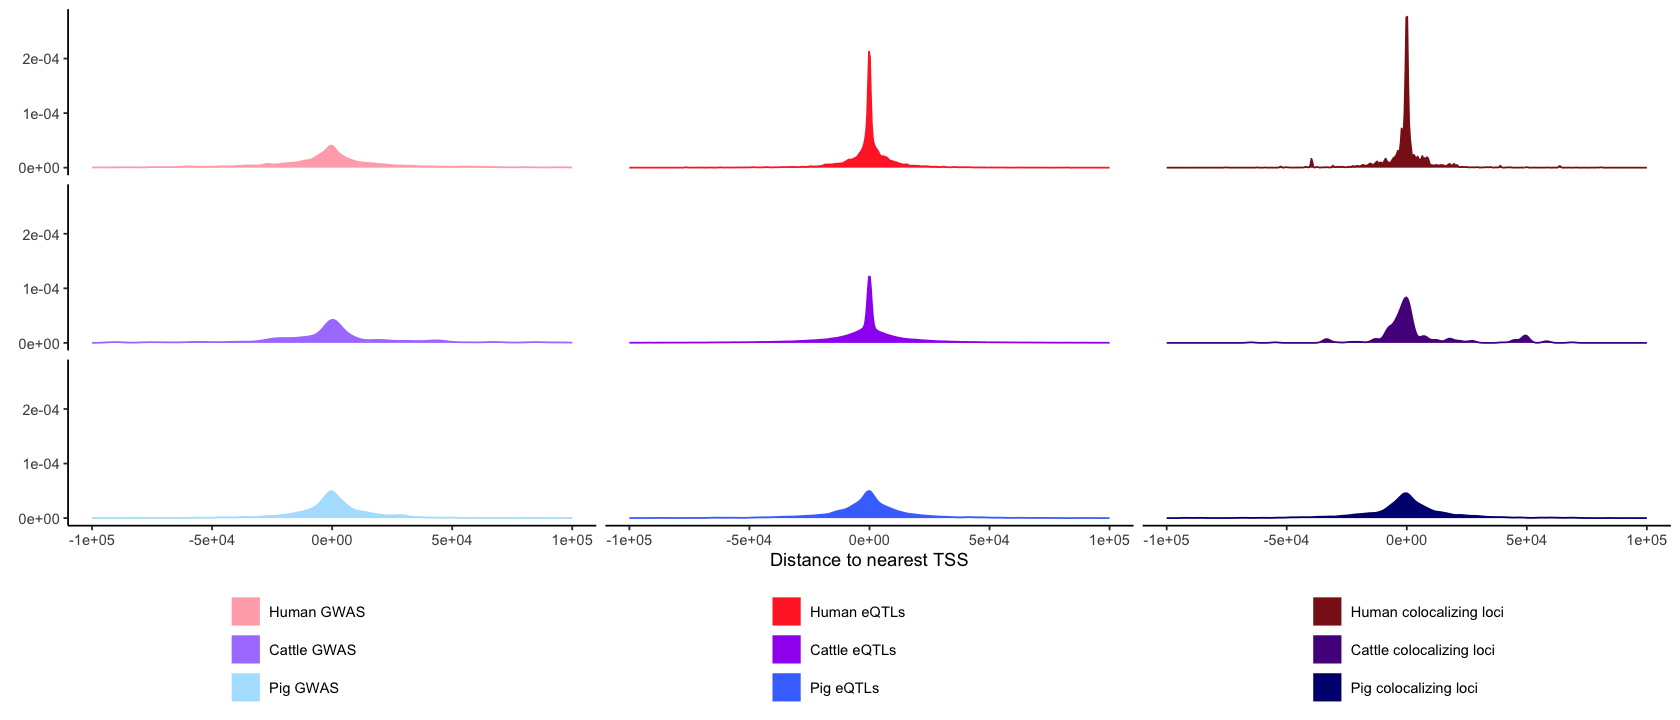

In [63]:
# Same as above but scale=1
# fig_size(20,6)
fig_size(14,6)

cat_levels <- c('human gwas', 'cattle gwas', 'pig gwas', 
                'human eqtls', 'cattle eqtls', 'pig eqtls', 
                'human coloc', 'cattle coloc', 'pig coloc')


# spacer = strrep(' ', 140)
spacer = strrep(' ', 95)
mini_spacer = strrep(' ', 0)

all_snps %>% 
    mutate(category = factor(paste(species, snps), levels=cat_levels)) %>%
    mutate(snps = factor(snps, levels=c('gwas', 'eqtls', 'coloc'))) %>% 
    mutate(species = factor(species, levels=c('human', 'cattle', 'pig'))) %>% 
    distinct(variant, snps, species, trait, .keep_all=T) %>%
ggplot(aes(x=nearest_tss_dist, color=category, fill=category)) + geom_density() + theme_classic() +
    scale_color_manual(values=c('human gwas'=color_key[['human gwas']], 'human eqtls'=color_key[['human eqtls']], 'human coloc'=color_key[['human coloc']], 'pig gwas'=color_key[['pig gwas']], 'pig eqtls'=color_key[['pig eqtls']], 'pig coloc'=color_key[['pig coloc']], 'cattle gwas'=color_key[['cattle gwas']], 'cattle eqtls'=color_key[['cattle eqtls']], 'cattle coloc'=color_key[['cattle coloc']]),
        labels=c('human gwas'=paste0('Human GWAS', spacer), 'human eqtls'=paste0('Human eQTLs', spacer), 'human coloc'=paste0('Human colocalizing loci', mini_spacer), 'pig gwas'=paste0('Pig GWAS', spacer), 'pig eqtls'=paste0('Pig eQTLs', spacer), 'pig coloc'=paste0('Pig colocalizing loci', mini_spacer), 'cattle gwas'=paste0('Cattle GWAS', spacer), 'cattle eqtls'=paste0('Cattle eQTLs', spacer), 'cattle coloc'=paste0('Cattle colocalizing loci', mini_spacer)), drop=F) + theme(legend.title = element_blank()) +
    scale_fill_manual(values=c('human gwas'=color_key[['human gwas']], 'human eqtls'=color_key[['human eqtls']], 'human coloc'=color_key[['human coloc']], 'pig gwas'=color_key[['pig gwas']], 'pig eqtls'=color_key[['pig eqtls']], 'pig coloc'=color_key[['pig coloc']], 'cattle gwas'=color_key[['cattle gwas']], 'cattle eqtls'=color_key[['cattle eqtls']], 'cattle coloc'=color_key[['cattle coloc']]),
        labels=c('human gwas'=paste0('Human GWAS', spacer), 'human eqtls'=paste0('Human eQTLs', spacer), 'human coloc'=paste0('Human colocalizing loci', mini_spacer), 'pig gwas'=paste0('Pig GWAS', spacer), 'pig eqtls'=paste0('Pig eQTLs', spacer), 'pig coloc'=paste0('Pig colocalizing loci', mini_spacer), 'cattle gwas'=paste0('Cattle GWAS', spacer), 'cattle eqtls'=paste0('Cattle eQTLs', spacer), 'cattle coloc'=paste0('Cattle colocalizing loci', mini_spacer)), drop=F) + theme(legend.title = element_blank()) +
    facet_wrap(species~snps) + xlim(-1e5, 1e5) + theme(legend.position='bottom', strip.text = element_blank()) + guides(color=guide_legend(ncol=3)) +
    ylab(element_blank()) + xlab('Distance to nearest TSS')

Warning message:
“Removed 12061 rows containing non-finite outside the scale range
(`stat_density()`).”


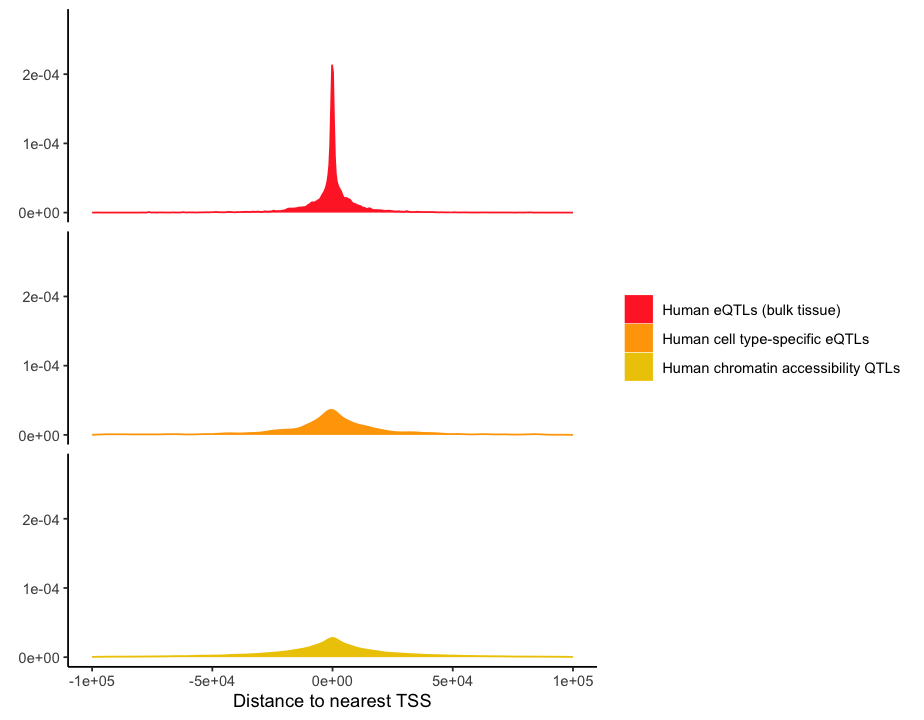

In [64]:
fig_size(7.70,6)

cat_levels <- c('human gwas', 'cattle gwas', 'pig gwas', 
                'human eqtls', 'cattle eqtls', 'pig eqtls', 
                'human coloc', 'cattle coloc', 'pig coloc', 'human sc-eqtls', 'human caqtls')

rbind(
    all_snps %>%  
        distinct(variant, snps, species, trait, .keep_all=T) %>%
        filter(species == 'human', snps == 'eqtls') %>%
        select(species, nearest_tss_dist, snps),
    jax %>% mutate(species='human', snps='sc-eqtls', category='human sc-eqtls') %>% select(species, nearest_tss_dist, snps),
    ca %>% mutate(species='human', snps='caqtls', category='human caqtls') %>% select(species, nearest_tss_dist, snps)
) %>% 
    mutate(category = factor(paste(species, snps), levels=cat_levels)) %>%
    mutate(snps = factor(snps, levels=c('gwas', 'eqtls', 'coloc', 'sc-eqtls', 'caqtls'))) %>% 
    mutate(species = factor(species, levels=c('human', 'cattle', 'pig'))) %>%
ggplot(aes(x=nearest_tss_dist, color=category, fill=category)) + geom_density() + theme_classic() +
    scale_color_manual(values=c('human eqtls'=color_key[['human eqtls']], 'human sc-eqtls'=color_key[['human sc-eqtls']], 'human caqtls'=color_key[['human caqtls']]),
        labels=c('human eqtls'='Human eQTLs (bulk tissue)', 'human sc-eqtls'='Human cell type-specific eQTLs', 'human caqtls'='Human chromatin accessibility QTLs'), drop=F) + theme(legend.title = element_blank()) +
    scale_fill_manual(values=c('human eqtls'=color_key[['human eqtls']], 'human sc-eqtls'=color_key[['human sc-eqtls']], 'human caqtls'=color_key[['human caqtls']]),
        labels=c('human eqtls'='Human eQTLs (bulk tissue)', 'human sc-eqtls'='Human cell type-specific eQTLs', 'human caqtls'='Human chromatin accessibility QTLs'), drop=F) + theme(legend.title = element_blank()) +
    facet_grid(snps~.) + xlim(-1e5, 1e5) + theme(strip.text = element_blank()) + guides(color=guide_legend(ncol=1)) +
    ylab(element_blank()) + xlab('Distance to nearest TSS') + ylim(0, 2.8e-4)

# Figure 4: PhyloP scores

First we need to get everything in human coordinates

In [65]:
lift_pig_positions_to_hg38 = function(df) {
    if (!('chr' %in% names(df))) stop('df must have a column named chr')
    if (!('start' %in% names(df) && 'end' %in% names(df)) && 'pos' %in% names(df)) {
        df$start = df$end = as.numeric(df$pos)
    } else if (!('start' %in% names(df) && 'end' %in% names(df)) && 'bp' %in% names(df)) {
        df$start = df$end = as.numeric(df$bp)
    } else if (!('start' %in% names(df) && 'end' %in% names(df))) {
        stop('df must have columns named start and end or pos or bp')
    }

    # If chr is not a string or does not start with 'chr', add 'chr' to the beginning
    if (class(df$chr) != 'character' || !all(grepl('^chr', df$chr))) df$chr = paste0('chr', df$chr)

    susscr11 = GenomicRanges::makeGRangesFromDataFrame(df, keep.extra.columns=T, ignore.strand=T)
    genome(susscr11) = 'susScr11'

    chain = '/Users/noah/data/liftover/susScr11ToHg38.over.chain' # Note that this cannot be gzipped
    hg38 = easylift::easylift(susscr11, to='hg38', chain)

    out = data.frame(hg38)
    if ('pos' %in% names(out)) out$pos = out$end
    if ('bp' %in% names(out)) out$bp = out$end
    out = out %>% dplyr::rename(chr=seqnames) %>% dplyr::select(-width, -strand) #dplyr::select(-start, -end, -strand, -width)
    return(out)
}

lift_cattle_positions_to_hg38 = function(df) {
    if (!('chr' %in% names(df))) stop('df must have a column named chr')
    if (!('start' %in% names(df) && 'end' %in% names(df)) && 'pos' %in% names(df)) {
        df$start = df$end = as.numeric(df$pos)
    } else if (!('start' %in% names(df) && 'end' %in% names(df)) && 'bp' %in% names(df)) {
        df$start = df$end = as.numeric(df$bp)
    } else if (!('start' %in% names(df) && 'end' %in% names(df))) {
        stop('df must have columns named start and end or pos or bp')
    }

    # If chr is not a string or does not start with 'chr', add 'chr' to the beginning
    if (class(df$chr) != 'character' || !all(grepl('^chr', df$chr))) df$chr = paste0('chr', df$chr)

    bostau9 = GenomicRanges::makeGRangesFromDataFrame(df, keep.extra.columns=T, ignore.strand=T)
    genome(bostau9) = 'bosTau9'

    chain = '/Users/noah/data/liftover/bosTau9ToHg38.over.chain' # Note that this cannot be gzipped
    hg38 = easylift::easylift(bostau9, to='hg38', chain)

    out = data.frame(hg38)
    if ('pos' %in% names(out)) out$pos = out$end
    if ('bp' %in% names(out)) out$bp = out$end
    out = out %>% dplyr::rename(chr=seqnames) %>% dplyr::select(-width, -strand) #dplyr::select(-start, -end, -strand, -width)
    return(out)
}

In [68]:
hvars = rbind(
    hgwas %>% select(chr, start, end, trait, tss_dist, variant) %>% mutate(nearest_tss_dist=tss_dist, snps='human gwas'), 
    heqtls %>% mutate(trait=paste0(tissue, ':', 'gene'), snps='human eqtls') %>% select(chr, start, end, trait, tss_dist, nearest_tss_dist, snps, variant),
    henloc %>% mutate(trait=paste0(tissue, ':', gene, ':', trait), variant=paste(chr, end, a1, a2, sep=':'), snps='human coloc') %>% select(chr, start, end, trait, tss_dist, nearest_tss_dist, snps, variant)#,
    # hsceqtls %>% mutate(variant = gsub('_', ':', gsub('_b37', '', snp)), trait=paste0(celltype, ':', gene), tss_dist=NA, nearest_tss_dist=NA, snps='human sc-eqtls')
    #     %>% select(chr, start, end, trait, tss_dist, nearest_tss_dist, snps, variant),
    # hcaqtls %>% mutate(variant=varID, trait=cell, tss_dist=NA, nearest_tss_dist=NA, snps='human caqtls') %>% select(chr, start, end, trait, tss_dist, nearest_tss_dist, snps, variant)
)


pvars = rbind(
    pgwas %>% select(chr, start, end, trait, variant, tss_dist) %>% mutate(nearest_tss_dist = tss_dist, snps = 'pig gwas'),
    peqtls %>% mutate(trait = paste0(tissue, ':', gene), snps = 'pig eqtls') %>% select(chr, start, end, trait, variant, snps, tss_dist, nearest_tss_dist),
    penloc %>% mutate(trait = paste0(tissue, ':', gene, ':', trait), snps = 'pig coloc') %>% select(chr, start, end, trait, variant, snps, tss_dist, nearest_tss_dist)
)

pvars_hg38 = lift_pig_positions_to_hg38(pvars)
write.table(pvars_hg38 %>% select(chr, start, end) %>% distinct(), '~/tmp/human_positions.bed', row.names=F, col.names=F, quote=F, sep='\t')
write.table(pvars_hg38 %>% select(chr, start, end) %>% distinct(), '~/tmp/pig_variants_hg38.bed', row.names=F, col.names=F, quote=F, sep='\t')

cvars = rbind(
    cgwas %>% select(chr, start, end, trait, variant, tss_dist) %>% mutate(nearest_tss_dist = tss_dist, snps = 'cattle gwas'),
    ceqtls %>% mutate(trait = paste0(tissue, ':', gene), snps = 'cattle eqtls') %>% select(chr, start, end, trait, variant, tss_dist, nearest_tss_dist, snps),
    cenloc %>% mutate(trait = paste0(tissue, ':', gene, ':', trait), snps = 'cattle coloc') %>% select(chr, start, end, trait, variant, tss_dist, nearest_tss_dist, snps)
)

cvars_hg38 = lift_cattle_positions_to_hg38(cvars)
write.table(cvars_hg38 %>% select(chr, start, end) %>% distinct(), '~/tmp/cattle_variants_hg38.bed', row.names=F, col.names=F, quote=F, sep='\t')

Because the PhyloP data are very large, it is better to extract all relevant GWAS/eQTL/colocalizing loci positions before reading into R.

Easily done with awk.

```
for autos in $(seq 1 22); do chr="chr$autos"; echo $chr; awk -v chrom=$chr 'NR == FNR && $1 == chrom {pos[$3]=1; next} $3 in pos' human_positions.bed  <(zcat /n/data2/hms/dbmi/sunyaev/lab/emkoch/raKLette/data/phylogenetic_constraint/zoonomia_phylop_mammals/$chr.bed.gz) > outputs/hvars_phylop_$chr.tsv; done
cat outputs/hvars_phylop_chr{1..22}.tsv > outputs_combined/hvars_phylop.tsv

for autos in $(seq 1 22); do chr="chr$autos"; echo $chr; awk -v chrom=$chr 'NR == FNR && $1 == chrom {pos[$3]=1; next} $3 in pos' pig_variants_hg38.bed <(zcat /n/data2/hms/dbmi/sunyaev/lab/emkoch/raKLette/data/phylogenetic_constraint/zoonomia_phylop_mammals/$chr.bed.gz) > outputs/pvars_phylop_$chr.tsv; done
cat outputs/pvars_phylop_chr{1..22}.tsv > outputs_combined/pvars_phylop.tsv

for autos in $(seq 1 22); do chr="chr$autos"; echo $chr; awk -v chrom=$chr 'NR == FNR && $1 == chrom {pos[$3]=1; next} $3 in pos' cattle_variants_hg38.bed <(zcat /n/data2/hms/dbmi/sunyaev/lab/emkoch/raKLette/data/phylogenetic_constraint/zoonomia_phylop_mammals/$chr.bed.gz) > outputs/cvars_phylop_$chr.tsv; done
cat outputs/cvars_phylop_chr{1..22}.tsv > outputs_combined/cvars_phylop.tsv
```

In [73]:
hphylop = read.table('~/comparative_colocalization/data/phylop/scores/hvars_phylop.tsv', header=F, as.is=T, sep='\t', col.names=c('chr', 'start', 'end', 'id', 'phylop'), fill=T) %>%
    select(-id) %>% na.omit

hvars_pp = hvars %>% left_join(hphylop, by=c('chr', 'start', 'end'))

pphylop = read.table('~/comparative_colocalization/data/phylop/scores/pvars_phylop.tsv', header=F, as.is=T, sep='\t', col.names=c('chr', 'start', 'end', 'id', 'phylop'), fill=T) %>%
    select(-id) %>% na.omit

pvars_pp = pvars_hg38 %>% left_join(pphylop, by=c('chr', 'start', 'end'))

cphylop = read.table('~/comparative_colocalization/data/phylop/scores/cvars_phylop.tsv', header=F, as.is=T, sep='\t', col.names=c('chr', 'start', 'end', 'id', 'phylop'), fill=T) %>%
    select(-id) %>% na.omit

cvars_pp = cvars_hg38 %>% left_join(cphylop, by=c('chr', 'start', 'end'))

all_pp_orig = rbind(hvars_pp, pvars_pp, cvars_pp) %>%
    separate_wider_delim(snps, ' ', names=c('species', 'type'), cols_remove=F) %>%
    mutate(snps = factor(snps, levels=categories_factor))

# all_pp_orig_pleio = all_pp_orig

all_pp_orig = all_pp_orig %>%
    mutate(trait_wo_tiss = gsub('^[^:]+:([^:]+:[^:]+$)', '\\1', trait, perl=T)) %>%
    filter(snps != 'human sc-eqtls', snps != 'human caqtls') %>%
    mutate(snps = factor(snps, levels=categories_factor)) %>%
    distinct(snps, trait_wo_tiss, variant, .keep_all=T) # This is specifically so I don't count the same variant-trait colocalization in many different tissues

# Even ignoring an eQTL for the same eGene in multiple tissues, one variant can be an eQTL for multiple eGenes.
# We don't want to count especially shared eQTLs too many times.
maxvar = 5
all_pp_orig = all_pp_orig %>%
group_by(snps, variant) %>%
slice_head(n=maxvar) %>%
ungroup()

Warning message:
“Removed 5897 rows containing non-finite outside the scale range
(`stat_summary()`).”
Warning message:
“Removed 5897 rows containing non-finite outside the scale range
(`stat_signif()`).”


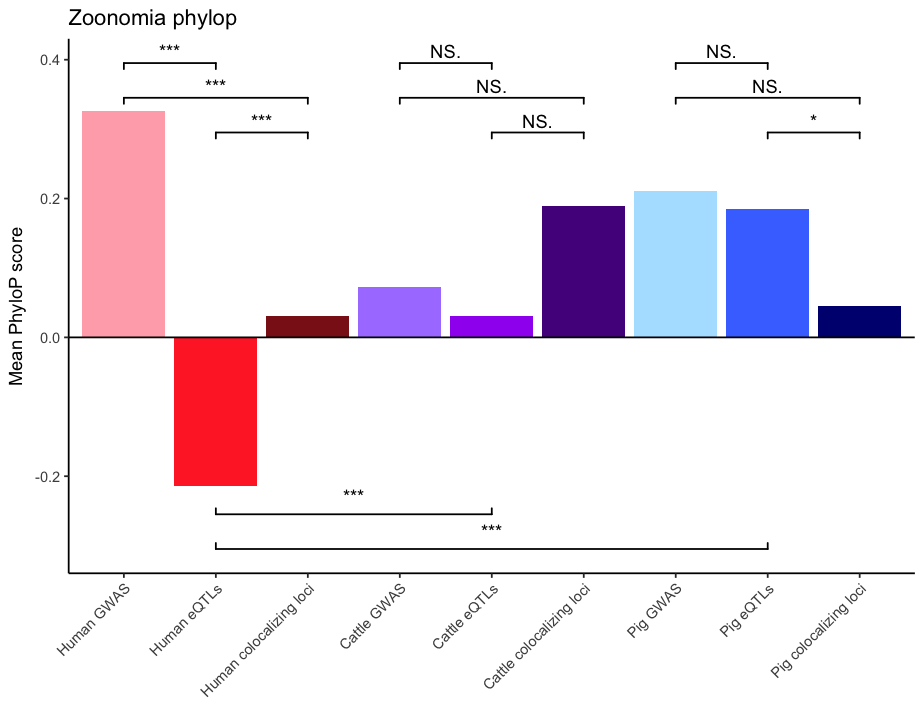

In [ ]:
all_pp_orig %>%
ggplot(aes(fill=snps, x=snps, y=phylop)) + geom_bar(stat='summary', fun='mean') + 
    theme_classic() +
    scale_fill_manual(
        values=c(
            'human gwas'=color_key[['human gwas']], 'human eqtls'=color_key[['human eqtls']], 'human coloc'=color_key[['human coloc']],
            'cattle gwas'=color_key[['cattle gwas']], 'cattle eqtls'=color_key[['cattle eqtls']], 'cattle coloc'=color_key[['cattle coloc']],
            'pig gwas'=color_key[['pig gwas']], 'pig eqtls'=color_key[['pig eqtls']], 'pig coloc'=color_key[['pig coloc']]
        ),
        labels=c(
            'human gwas'='Human GWAS', 'human eqtls'='Human eQTLs', 'human coloc'='Human colocalizing loci',
            'cattle gwas'='Cattle GWAS', 'cattle eqtls'='Cattle eQTLs', 'cattle coloc'='Cattle colocalizing loci',
            'pig gwas'='Pig GWAS', 'pig eqtls'='Pig eQTLs', 'pig coloc'='Pig colocalizing loci'
        ), drop=T) + theme(legend.title = element_blank()) +
    scale_x_discrete(labels=c('human gwas'='Human GWAS', 'human eqtls'='Human eQTLs', 'human coloc'='Human colocalizing loci', 'pig gwas'='Pig GWAS', 'pig eqtls'='Pig eQTLs', 'pig coloc'='Pig colocalizing loci', 'cattle gwas'='Cattle GWAS', 'cattle eqtls'='Cattle eQTLs', 'cattle coloc'='Cattle colocalizing loci')) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, hjust = 1)) + geom_hline(yintercept = 0) + ylab('Mean PhyloP score') + xlab(element_blank()) + ggtitle('Zoonomia phylop') + 
    geom_signif(
        comparisons = list(
            c('human gwas', 'human eqtls'), c('human gwas', 'human coloc'), c('human eqtls', 'human coloc'),
            c('cattle gwas', 'cattle eqtls'), c('cattle gwas', 'cattle coloc'), c('cattle eqtls', 'cattle coloc'),
            c('pig gwas', 'pig eqtls'), c('pig gwas', 'pig coloc'), c('pig eqtls', 'pig coloc'),
            c('human eqtls', 'cattle eqtls'), c('human eqtls', 'pig eqtls')
        ), 
        # map_signif_level = T,
        y_position = c(-1.05, -1.1, -1.15, -1.05, -1.1, -1.15, -1.05, -1.1, -1.15, -1.7, -1.75), 
        tip_length = c(0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, 0.0003, -0.0003, -0.0003),
        map_signif_level = c('***'=0.001, '**'=0.01, '*'=0.05)/11
    )

## Versions of fig 4 not included in paper

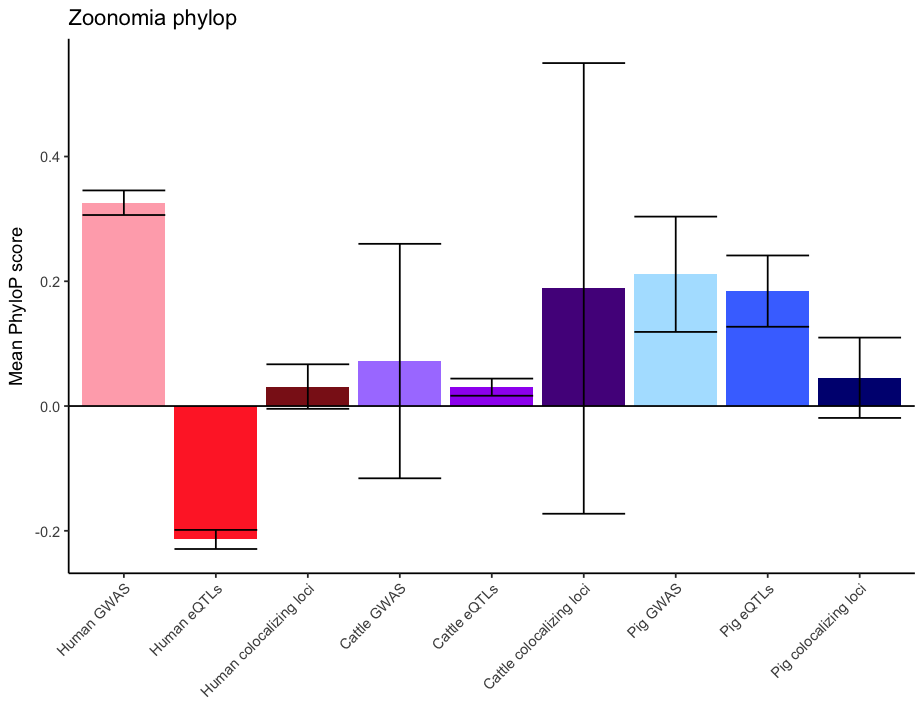

In [235]:
all_pp_orig %>%
group_by(snps) %>%
summarize(
    count = n(),
    med_phylop = median(phylop, na.rm=T),
    mean_phylop = mean(phylop, na.rm=T),
    sd_phylop = sd(phylop, na.rm=T),
    se_phylop = sd_phylop / sqrt(count),
    ci95_lower = mean_phylop - se_phylop * qt(0.975, count-1),
    ci95_upper = mean_phylop + se_phylop * qt(0.975, count-1)
) %>%
ggplot(aes(fill=snps, x=snps, y=mean_phylop)) + geom_bar(stat='identity') + geom_errorbar(aes(ymin=ci95_lower, ymax=ci95_upper)) +
    theme_classic() +
    scale_fill_manual(
        values=c(
            'human gwas'=color_key[['human gwas']], 'human eqtls'=color_key[['human eqtls']], 'human coloc'=color_key[['human coloc']],
            'cattle gwas'=color_key[['cattle gwas']], 'cattle eqtls'=color_key[['cattle eqtls']], 'cattle coloc'=color_key[['cattle coloc']],
            'pig gwas'=color_key[['pig gwas']], 'pig eqtls'=color_key[['pig eqtls']], 'pig coloc'=color_key[['pig coloc']]
        ),
        labels=c(
            'human gwas'='Human GWAS', 'human eqtls'='Human eQTLs', 'human coloc'='Human colocalizing loci',
            'cattle gwas'='Cattle GWAS', 'cattle eqtls'='Cattle eQTLs', 'cattle coloc'='Cattle colocalizing loci',
            'pig gwas'='Pig GWAS', 'pig eqtls'='Pig eQTLs', 'pig coloc'='Pig colocalizing loci'
        ), drop=T) + theme(legend.title = element_blank()) +
    scale_x_discrete(labels=c('human gwas'='Human GWAS', 'human eqtls'='Human eQTLs', 'human coloc'='Human colocalizing loci', 'pig gwas'='Pig GWAS', 'pig eqtls'='Pig eQTLs', 'pig coloc'='Pig colocalizing loci', 'cattle gwas'='Cattle GWAS', 'cattle eqtls'='Cattle eQTLs', 'cattle coloc'='Cattle colocalizing loci')) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, hjust = 1)) + geom_hline(yintercept = 0) + ylab('Mean PhyloP score') + xlab(element_blank()) + ggtitle('Zoonomia phylop')

Warning message:
“Removed 5897 rows containing non-finite outside the scale range
(`stat_summary()`).”
Warning message:
“Removed 5897 rows containing non-finite outside the scale range
(`stat_signif()`).”


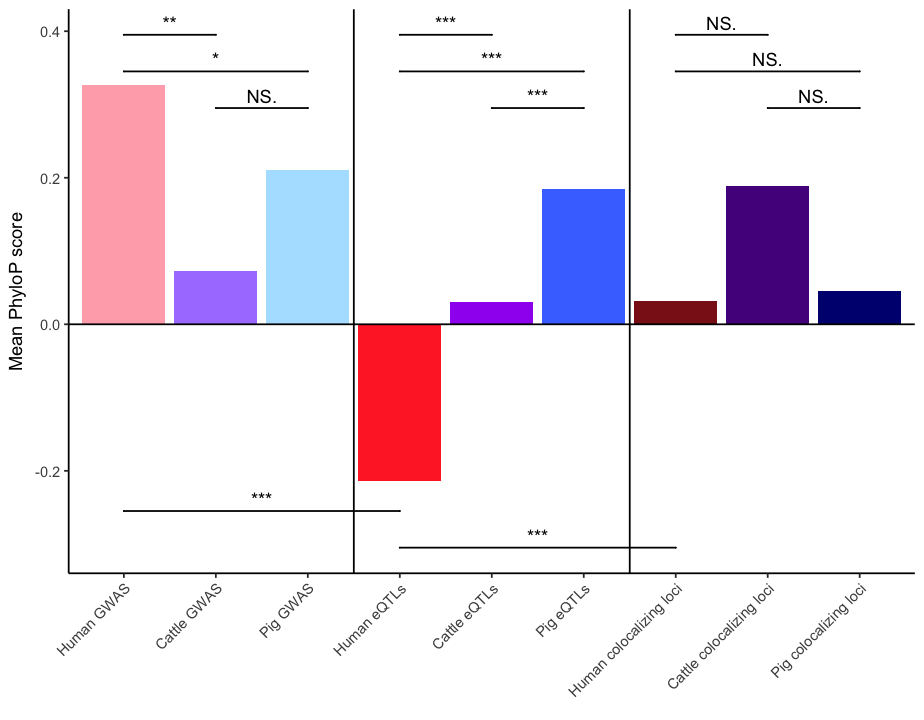

In [233]:
# Grouped by snp type
all_pp_orig %>%
    mutate(snps = factor(snps, levels=c('human gwas', 'cattle gwas', 'pig gwas', 'human eqtls', 'cattle eqtls', 'pig eqtls', 'human coloc', 'cattle coloc', 'pig coloc'))) %>%
ggplot(aes(fill=snps, x=snps, y=phylop)) + geom_bar(stat='summary', fun='mean') + 
    theme_classic() +
    scale_fill_manual(
        values=c(
            'human gwas'=color_key[['human gwas']], 'human eqtls'=color_key[['human eqtls']], 'human coloc'=color_key[['human coloc']],
            'cattle gwas'=color_key[['cattle gwas']], 'cattle eqtls'=color_key[['cattle eqtls']], 'cattle coloc'=color_key[['cattle coloc']],
            'pig gwas'=color_key[['pig gwas']], 'pig eqtls'=color_key[['pig eqtls']], 'pig coloc'=color_key[['pig coloc']]
        ),
        labels=c(
            'human gwas'='Human GWAS', 'human eqtls'='Human eQTLs', 'human coloc'='Human colocalizing loci',
            'cattle gwas'='Cattle GWAS', 'cattle eqtls'='Cattle eQTLs', 'cattle coloc'='Cattle colocalizing loci',
            'pig gwas'='Pig GWAS', 'pig eqtls'='Pig eQTLs', 'pig coloc'='Pig colocalizing loci'
        ), drop=T) + theme(legend.title = element_blank()) +
    scale_x_discrete(labels=c('human gwas'='Human GWAS', 'human eqtls'='Human eQTLs', 'human coloc'='Human colocalizing loci', 'pig gwas'='Pig GWAS', 'pig eqtls'='Pig eQTLs', 'pig coloc'='Pig colocalizing loci', 'cattle gwas'='Cattle GWAS', 'cattle eqtls'='Cattle eQTLs', 'cattle coloc'='Cattle colocalizing loci')) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, hjust = 1)) + geom_hline(yintercept = 0) + ylab('Mean PhyloP score') + xlab(element_blank())  + 
    geom_signif(
        comparisons = list(
            c('human gwas', 'cattle gwas'), c('human gwas', 'pig gwas'), c('cattle gwas', 'pig gwas'),
            c('human eqtls', 'cattle eqtls'), c('human eqtls', 'pig eqtls'), c('cattle eqtls', 'pig eqtls'),
            c('human coloc', 'cattle coloc'), c('human coloc', 'pig coloc'), c('cattle coloc', 'pig coloc'),
            c('human gwas', 'human eqtls'), c('human eqtls', 'human coloc')
        ), 
        map_signif_level = T,
        test = 't.test', 
        test.args = list(alternative = "two.sided", var.equal = FALSE, paired=FALSE),
        y_position = c(-1.05, -1.1, -1.15, -1.05, -1.1, -1.15, -1.05, -1.1, -1.15, -1.7, -1.75), 
        tip_length = 0
    ) + geom_vline(xintercept=3.5) + geom_vline(xintercept=6.5)

# Supplementary figure

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


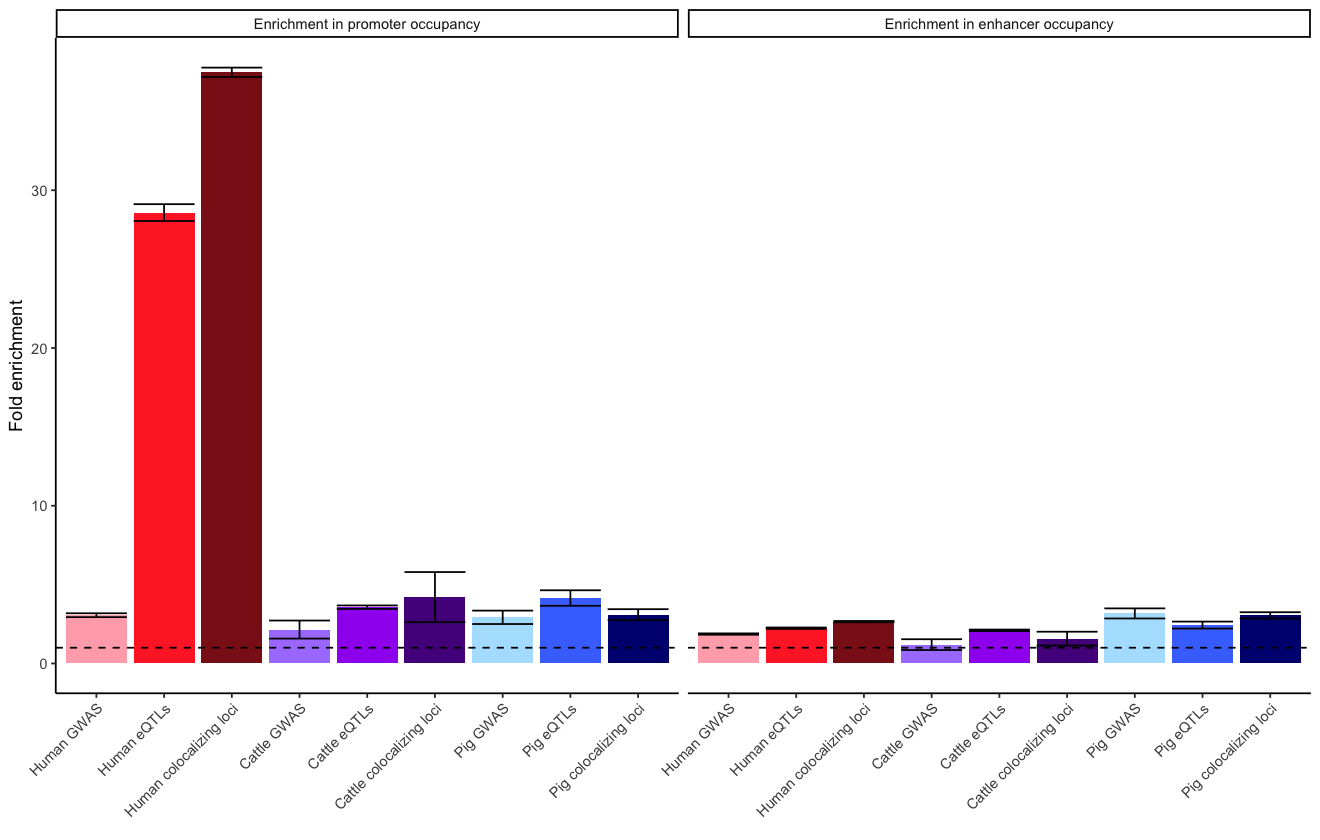

In [26]:
fig_size(11,7)

snp_categories = c('human gwas', 'human eqtls', 'human coloc', 'cattle gwas', 'cattle eqtls', 'cattle coloc', 'pig gwas', 'pig eqtls', 'pig coloc')

enr %>%
    select(-pro_frac, -enh_frac) %>%
    pivot_longer(cols = c(pro_enrich, enh_enrich), names_to = 'annot_category', values_to = 'enrichment') %>%
    mutate(category = factor(paste(species, snps), levels=snp_categories)) %>%
    mutate(annot_category = factor(annot_category, levels=c('pro_enrich', 'enh_enrich'))) %>%
ggplot(aes(y=enrichment, x=category, fill=category)) + 
    stat_summary(geom='bar', fun=mean, position='dodge') +
    stat_summary(geom='errorbar', fun.data=mean_se, position='dodge') +
    theme_classic() + geom_hline(yintercept = 1, size=0.5, linetype='dashed') +
    scale_fill_manual(values=c('human gwas'=color_key[['human gwas']], 'human eqtls'=color_key[['human eqtls']], 'human coloc'=color_key[['human coloc']], 'pig gwas'=color_key[['pig gwas']], 'pig eqtls'=color_key[['pig eqtls']], 'pig coloc'=color_key[['pig coloc']], 'cattle gwas'=color_key[['cattle gwas']], 'cattle eqtls'=color_key[['cattle eqtls']], 'cattle coloc'=color_key[['cattle coloc']]),
        labels=c('human gwas'='Human GWAS', 'human eqtls'='Human eQTLs', 'human coloc'='Human colocalizing loci', 'pig gwas'='Pig GWAS', 'pig eqtls'='Pig eQTLs', 'pig coloc'='Pig colocalizing loci', 'cattle gwas'='Cattle GWAS', 'cattle eqtls'='Cattle eQTLs', 'cattle coloc'='Cattle colocalizing loci'), drop=T) + theme(legend.title = element_blank()) +
    scale_x_discrete(labels=c('human gwas'='Human GWAS', 'human eqtls'='Human eQTLs', 'human coloc'='Human colocalizing loci', 'pig gwas'='Pig GWAS', 'pig eqtls'='Pig eQTLs', 'pig coloc'='Pig colocalizing loci', 'cattle gwas'='Cattle GWAS', 'cattle eqtls'='Cattle eQTLs', 'cattle coloc'='Cattle colocalizing loci')) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, hjust = 1)) + ylab('Fold enrichment') + xlab(element_blank()) + 
    facet_wrap(~annot_category, labeller=as_labeller(c(`pro_enrich`='Enrichment in promoter occupancy', `enh_enrich`='Enrichment in enhancer occupancy')))